In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

In [4]:
tips = sns.load_dataset("tips")

In [5]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [7]:
tips['total_bill'].mean()

np.float64(19.78594262295082)

In [8]:
bill = tips['total_bill']

In [9]:
bill.describe()

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64

In [11]:
bill.mean(), bill.median()

(np.float64(19.78594262295082), np.float64(17.795))

In [14]:
bill.std() / bill.mean()

np.float64(0.44993620594706724)

In [15]:
bill.head()

0    16.99
1    10.34
2    21.01
3    23.68
4    24.59
Name: total_bill, dtype: float64

<Axes: >

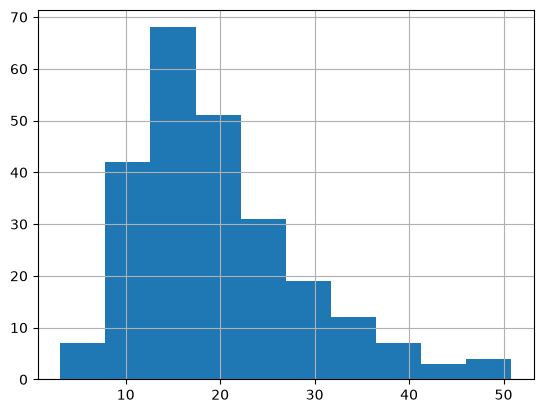

In [19]:
bill.hist()

c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

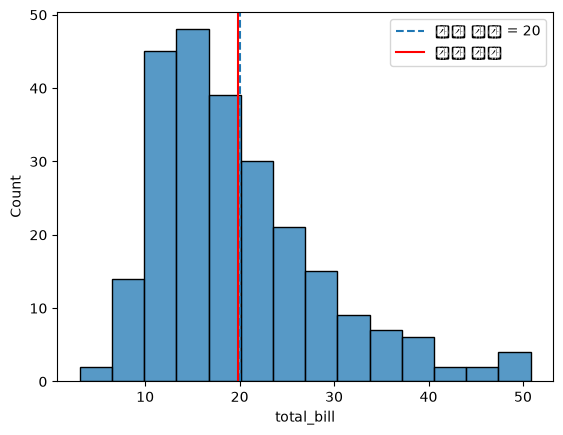

In [26]:
sns.histplot(bill)
plt.axvline(20, linestyle="--", label="기준 평균 = 20")
plt.axvline(bill.mean(), color="red", label="표본 평균")
plt.legend()
plt.show()

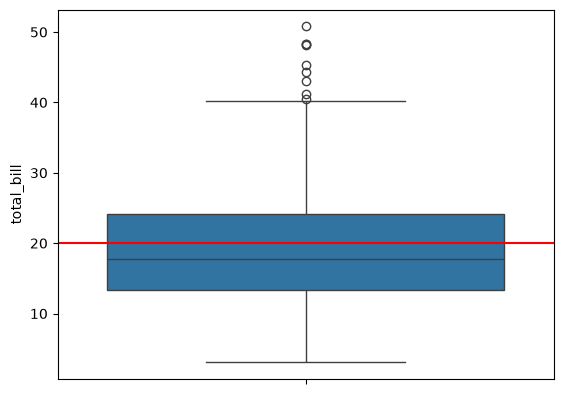

In [30]:
sns.boxplot(bill)
plt.axhline(20, color="red")

In [34]:
result = stats.ttest_1samp(bill, popmean=20)
result

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))

In [35]:
stats.ttest_1samp(bill, 20)

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))

In [40]:
result.confidence_interval

<bound method TtestResult.confidence_interval of TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))>

In [41]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("평균 결제금액은 20달러와 통계적으로 다르다고 볼 수 있다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("평균 결제금액이 20달러와 다르다고 볼 충분한 근거가 없다.")

귀무가설을 기각하지 못한다.
평균 결제금액이 20달러와 다르다고 볼 충분한 근거가 없다.


In [42]:
result

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))

In [50]:
(bill.mean() - 20) / (bill.std()/np.sqrt(bill.count()))

np.float64(-0.37559294451919506)

In [52]:
stats.ttest_1samp(bill, 20)

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))

In [53]:
stats.ttest_1samp(bill, 20, alternative="two-sided")

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))

In [54]:
stats.ttest_1samp(bill, 20, alternative="greater")

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.646226403218664), df=np.int64(243))

In [55]:
stats.ttest_1samp(bill, 20, alternative="less")

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.3537735967813361), df=np.int64(243))

In [56]:
se = bill.std()/np.sqrt(bill.count())
se

np.float64(0.5699185252885925)

In [57]:
bill.mean()-se, bill.mean()+se

(np.float64(19.216024097662228), np.float64(20.355861148239413))

In [59]:
t = stats.t.ppf(0.975, 243)
t

np.float64(1.9697743954267473)

In [60]:
bill.mean()-t*se

np.float64(18.66333170435798)

In [61]:
bill.mean()+t*se

np.float64(20.90855354154366)

In [62]:
bill.mean()-1.96*se, bill.mean()+1.96*se

(np.float64(18.66890231338518), np.float64(20.902982932516462))

In [63]:
stats.norm.ppf(0.975)

np.float64(1.959963984540054)

In [64]:
stats.t.ppf(0.975, 243)

np.float64(1.9697743954267473)

In [65]:
result.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(18.66333170435798), high=np.float64(20.90855354154366))

In [66]:
bill.mean()-t*se, bill.mean()+t*se

(np.float64(18.66333170435798), np.float64(20.90855354154366))

In [67]:
stats.norm.ppf(0.95)

np.float64(1.6448536269514722)

In [69]:
stats.norm.ppf(0.975)

np.float64(1.959963984540054)

In [71]:
stats.t.ppf(0.975, 243)

np.float64(1.9697743954267473)

In [72]:
result.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(18.66333170435798), high=np.float64(20.90855354154366))

표본 수: 244
표본평균: 19.78594262295082
표본표준편차: 8.902411954856856
중앙값: 17.795


c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

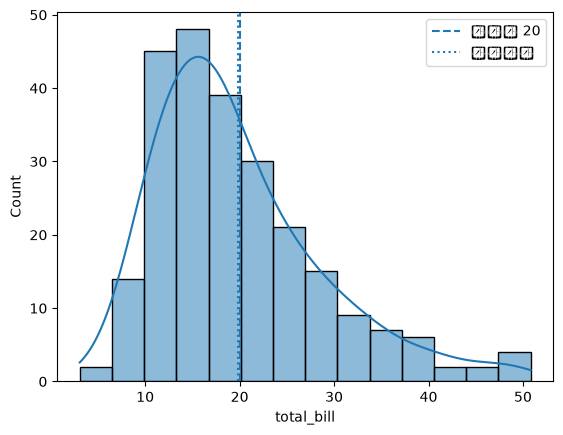

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))
귀무가설을 기각하지 못한다.
평균 총 결제금액이 20달러와 다르다는 통계적 근거가 부족하다.
직접 계산한 t 통계량: -0.37559294451919506
직접 계산한 p-value: 0.7075471935626721
95% 신뢰구간: 18.66333170435798 20.90855354154366


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats


# 1. 데이터 불러오기
tips = sns.load_dataset("tips")


# 2. 분석할 변수 선택 및 결측치 제거
bill = tips["total_bill"].dropna()


# 3. 데이터 확인
print("표본 수:", bill.count())
print("표본평균:", bill.mean())
print("표본표준편차:", bill.std(ddof=1))
print("중앙값:", bill.median())


# 4. 시각화
sns.histplot(bill, kde=True)
plt.axvline(
    20,
    linestyle="--",
    label="기준값 20"
)
plt.axvline(
    bill.mean(),
    linestyle=":",
    label="표본평균"
)
plt.legend()
plt.show()


# 5. 가설검정
# H0: 평균 총 결제금액은 20달러이다.
# H1: 평균 총 결제금액은 20달러가 아니다.

result = stats.ttest_1samp(
    bill,
    popmean=20,
    alternative="two-sided"
)

print(result)


# 6. 결과 해석
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("평균 총 결제금액은 20달러와 통계적으로 다르다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("평균 총 결제금액이 20달러와 다르다는 통계적 근거가 부족하다.")


# 7. t 통계량 직접 계산
sample_mean = bill.mean()
sample_std = bill.std(ddof=1)
n = bill.count()
pop_mean = 20

standard_error = sample_std / np.sqrt(n)

t_stat = (
    sample_mean - pop_mean
) / standard_error

print("직접 계산한 t 통계량:", t_stat)


# 8. p-value 직접 계산
df = n - 1

p_value = 2 * stats.t.sf(
    np.abs(t_stat),
    df=df
)

print("직접 계산한 p-value:", p_value)


# 9. 95% 신뢰구간
critical_t = stats.t.ppf(
    0.975,
    df=df
)

margin_error = critical_t * standard_error

lower = sample_mean - margin_error
upper = sample_mean + margin_error

print("95% 신뢰구간:", lower, upper)

In [4]:
tip = tips.tip

In [6]:
tip.describe()

count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64

In [7]:
stats.ttest_1samp(tip, 3)

TtestResult(statistic=np.float64(-0.019432641422916876), pvalue=np.float64(0.9845119176410543), df=np.int64(243))

In [12]:
# p-value는 0.98로 0.98 > 0.05 이므로 H0를 기각하지 못한다. 따라서 tip은 3달러와 다르다고 볼 근거가 부족하다

In [9]:
stats.ttest_1samp(tip, 3, alternative="two-sided")

TtestResult(statistic=np.float64(-0.019432641422916876), pvalue=np.float64(0.9845119176410543), df=np.int64(243))

In [10]:
tip.isna().sum()

np.int64(0)

In [11]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("평균 팁 금액은 3달러와 다르다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("평균 팁 금액이 3달러와 다르다고 볼 근거가 부족하다.")

귀무가설을 기각하지 못한다.
평균 팁 금액이 3달러와 다르다고 볼 근거가 부족하다.


In [ ]:
# H0: mu <= 2.5
# H1: mu > 2.5

In [13]:
stats.ttest_1samp(tip, 2.5, alternative="greater")

TtestResult(statistic=np.float64(5.625287009994554), pvalue=np.float64(2.539994229843246e-08), df=np.int64(243))

In [14]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("평균 팁 금액은 2.5달러보다 크다고 볼 수 있다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("평균 팁 금액이 2.5달러보다 크다고 볼 근거가 부족하다.")

귀무가설을 기각하지 못한다.
평균 팁 금액이 2.5달러보다 크다고 볼 근거가 부족하다.


In [15]:
# p-value가 2.54로 0.05보다 크므로 H0를 기각하지 못한다. 따라서 평균 팁 금액이 2.5달러보다 크다고 볼 근거가 부족하다

In [16]:
weights = np.array([
    498, 503, 501, 497, 504,
    499, 502, 500, 505, 496,
    501, 499, 503, 498, 500,
    502, 497, 504, 501, 499
])

In [23]:
# H0 = 500
# H1 != 500

In [24]:
len(weights)

20

In [25]:
stats.ttest_1samp(weights, 500, alternative="two-sided")

TtestResult(statistic=np.float64(0.7785526001758747), pvalue=np.float64(0.4458317162792534), df=np.int64(19))

In [27]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설 기각")
    print("제품 평균 무게는 500g과 다르다고 볼 수 있다.")
else:
    print("귀무가설을 기각하지 못함")
    print("제품 평균 무게가 500g과 다르다고 볼 근거가 부족하다.")

귀무가설을 기각하지 못함
제품 평균 무게가 500g과 다르다고 볼 근거가 부족하다.


In [28]:
# p-value가 0.446정도로 0.05보다 크므로, H0를 기각하지 못한다. 따라서 weights의 평균이 500과 다르다고 볼 근거가 부족하다.

In [29]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [30]:
# 남자 모집단 평균 mu1
# 여자 모집단 평균 mu2
# H0: mu1 = mu2
# H1: mu1 != mu2

In [31]:
tips['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [34]:
tips.groupby('sex')['total_bill'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
sex,,,,
Male,157,20.744076,9.246469,18.35
Female,87,18.056897,8.009209,16.40


In [42]:
male_bill = tips.loc[tips.sex == 'Male','total_bill']
male_bill

1      10.34
2      21.01
3      23.68
5      25.29
6       8.77
       ...  
236    12.60
237    32.83
239    29.03
241    22.67
242    17.82
Name: total_bill, Length: 157, dtype: float64

In [43]:
female_bill = tips.loc[tips['sex']=='Female', 'total_bill']
female_bill

0      16.99
4      24.59
11     35.26
14     14.83
16     10.33
       ...  
226    10.09
229    22.12
238    35.83
240    27.18
243    18.78
Name: total_bill, Length: 87, dtype: float64

In [44]:
male_bill.mean(), female_bill.mean()

(np.float64(20.744076433121016), np.float64(18.056896551724133))

In [45]:
male_bill.mean()-female_bill.mean()

np.float64(2.687179881396883)

<Axes: xlabel='sex', ylabel='total_bill'>

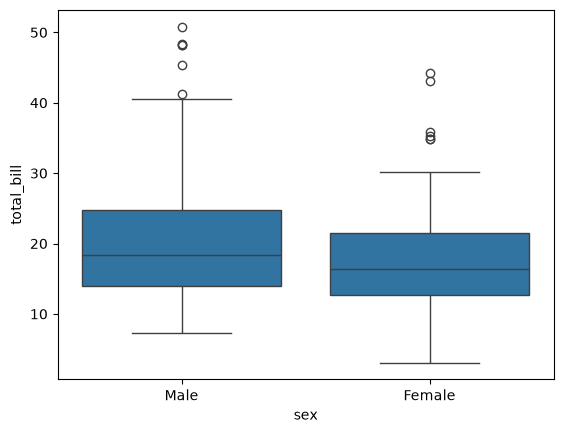

In [49]:
sns.boxplot(tips, x='sex', y='total_bill')

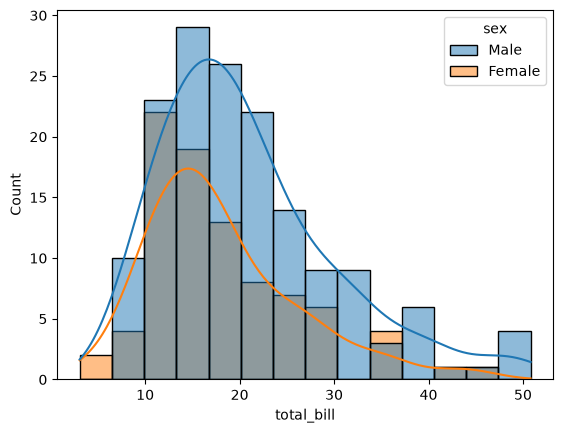

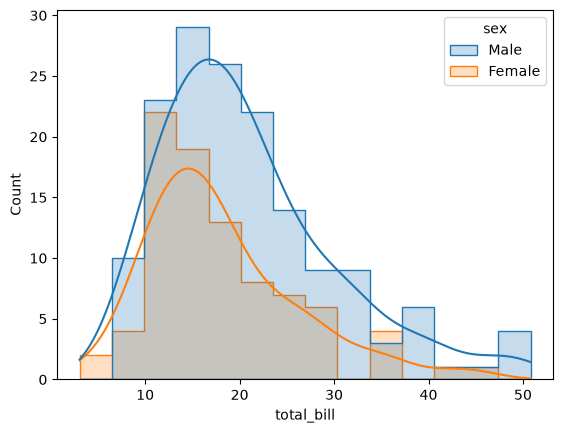

In [56]:
sns.histplot(tips, x='total_bill', hue='sex', kde=True)
plt.show()
sns.histplot(tips, x='total_bill', hue='sex', kde=True, element='step')
plt.show()

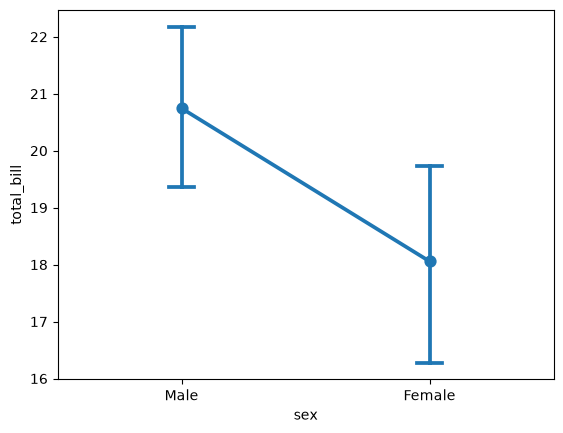

In [57]:
sns.pointplot(
    data=tips,
    x="sex",
    y="total_bill",
    errorbar=("ci", 95),
    capsize=0.1
)

plt.show()

In [ ]:
# 정규성 확인: shapiro
# H0: 데이터가 정규분포를 따른다
# H1: 데이터가 정규분포를 따르지 않는다

In [61]:
print(stats.shapiro(male_bill).pvalue)

1.0274536685915797e-07


In [62]:
if stats.shapiro(male_bill).pvalue < 0.05:
    print("남성 집단은 정규성을 만족하지 않는다고 판단")
else:
    print("남성 집단의 정규성을 기각하지 못함")

남성 집단은 정규성을 만족하지 않는다고 판단


In [63]:
stats.shapiro(female_bill).pvalue

np.float64(4.211812241575293e-05)

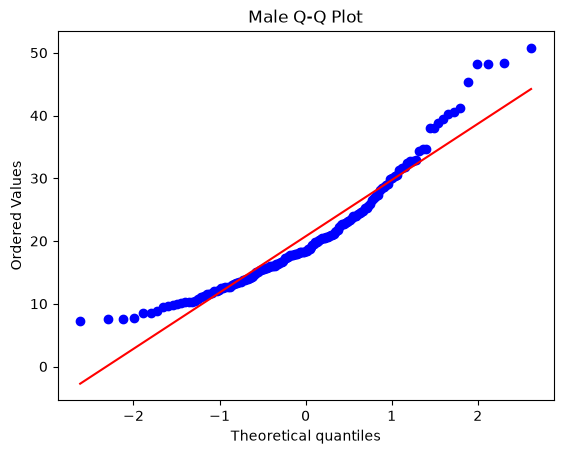

In [64]:
stats.probplot(
    male_bill,
    dist="norm",
    plot=plt
)

plt.title("Male Q-Q Plot")
plt.show()

((array([-2.61932342, -2.3011455 , -2.11897341, -1.98808743, -1.88439676,
         -1.79772477, -1.72277103, -1.65640788, -1.59662845, -1.54206475,
         -1.49174058, -1.44493383, -1.40109463, -1.35979412, -1.32069108,
         -1.28350932, -1.24802199, -1.21404037, -1.18140564, -1.14998288,
         -1.11965636, -1.09032607, -1.06190494, -1.03431666, -1.00749397,
         -0.98137721, -0.95591324, -0.9310545 , -0.9067582 , -0.88298572,
         -0.85970207, -0.83687542, -0.81447672, -0.79247938, -0.77085899,
         -0.74959307, -0.72866087, -0.70804319, -0.68772219, -0.6676813 ,
         -0.64790506, -0.62837904, -0.60908972, -0.59002442, -0.57117122,
         -0.5525189 , -0.53405686, -0.51577509, -0.49766411, -0.47971492,
         -0.46191898, -0.44426815, -0.42675466, -0.40937111, -0.3921104 ,
         -0.37496573, -0.35793059, -0.34099869, -0.324164  , -0.30742069,
         -0.29076313, -0.27418586, -0.25768361, -0.24125123, -0.22488375,
         -0.2085763 , -0.19232412, -0.

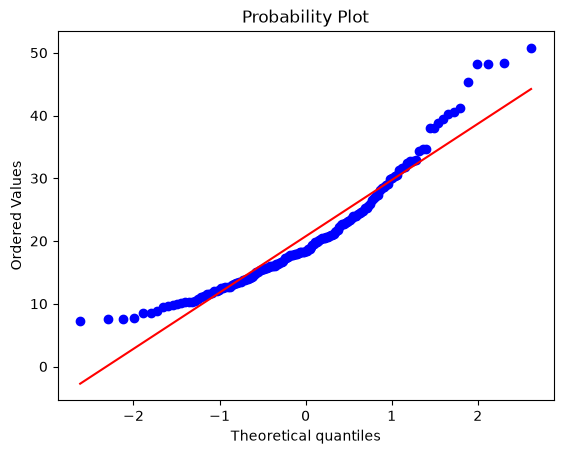

In [68]:
stats.probplot(male_bill, dist='norm', plot=plt)

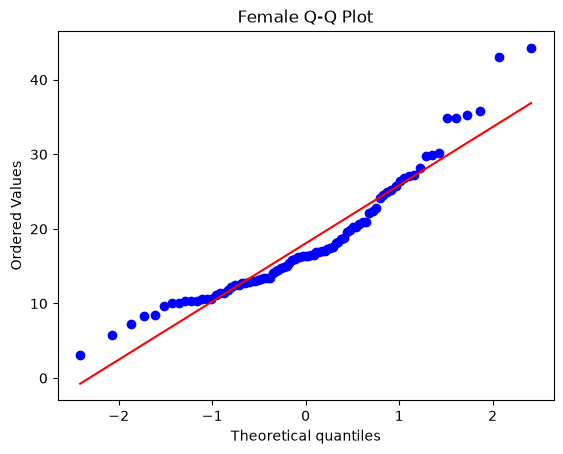

In [69]:
stats.probplot(
    female_bill,
    dist="norm",
    plot=plt
)

plt.title("Female Q-Q Plot")
plt.show()

In [ ]:
# 등분산성 확인
# H0: 두 집단의 분산이 같다
# H1: 두 집단의 분산이 다르다

stats.levene(male_bill, female_bill)

LeveneResult(statistic=np.float64(1.631715567905501), pvalue=np.float64(0.20269005267784007))

In [72]:
if stats.levene(male_bill, female_bill).pvalue < 0.05:
    print('H0 기각: 두 집단의 분산은 다르다')
else:
    print('H0를 기각하지 못한다: 두 집단의 분산은 같다')

H0를 기각하지 못한다: 두 집단의 분산은 같다


In [74]:
ttest = stats.ttest_ind(male_bill, female_bill, equal_var=True, alternative='two-sided')
ttest

TtestResult(statistic=np.float64(2.2777940289803134), pvalue=np.float64(0.023611666846859423), df=np.float64(242.0))

In [75]:
# H0: 남자와 여자의 total_bill의 평균은 같다
# H1: 남자와 여자의 total_bill의 평균은 다르다

In [76]:
if ttest.pvalue < 0.05:
    print('H0 기각: H1 채택 (평균은 다르다)')
else:
    print('H0 기각 못함: H0를 기각할 근거가 부족하므로 두 집단의 평균은 같다')

H0 기각: H1 채택 (평균은 다르다)


In [78]:
alpha = 0.05

if ttest.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("남성과 여성 고객의 평균 결제금액은 통계적으로 유의한 차이가 있다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("남성과 여성 고객의 평균 결제금액이 다르다고 볼 근거가 부족하다.")

귀무가설을 기각한다.
남성과 여성 고객의 평균 결제금액은 통계적으로 유의한 차이가 있다.


In [79]:
# H0 기각: 남성과 여성 고객의 평균 결제금액은 통계적으로 유의미한 차이가 있다.
# H1 기각: 남성과 여성 고객의 평균 결제금액은 다르다고 볼 근거가 부족하다.

In [80]:
stats.ttest_ind(male_bill, female_bill, equal_var=False, alternative="two-sided")

TtestResult(statistic=np.float64(2.3733978410287073), pvalue=np.float64(0.01857339485492169), df=np.float64(199.8482620471115))

In [81]:
alpha = 0.05

levene_result = stats.levene(
    male_bill,
    female_bill
)

if levene_result.pvalue >= alpha:
    equal_var = True
    variance_message = "등분산을 가정한 Student t-test"
else:
    equal_var = False
    variance_message = "등분산을 가정하지 않은 Welch t-test"

result = stats.ttest_ind(
    male_bill,
    female_bill,
    equal_var=equal_var,
    alternative="two-sided"
)

print("사용한 검정:", variance_message)
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("두 집단의 평균에는 유의한 차이가 있다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("두 집단의 평균이 다르다고 볼 근거가 부족하다.")

사용한 검정: 등분산을 가정한 Student t-test
t 통계량: 2.2777940289803134
p-value: 0.023611666846859423
귀무가설을 기각한다.
두 집단의 평균에는 유의한 차이가 있다.


In [82]:
stats.ttest_ind(male_bill, female_bill)

TtestResult(statistic=np.float64(2.2777940289803134), pvalue=np.float64(0.023611666846859423), df=np.float64(242.0))

In [83]:
stats.ttest_ind(female_bill, male_bill)

TtestResult(statistic=np.float64(-2.2777940289803134), pvalue=np.float64(0.023611666846859423), df=np.float64(242.0))

In [85]:
result_greater = stats.ttest_ind(
    male_bill,
    female_bill,
    equal_var=True,
    alternative="less"
)

print(result_greater)

TtestResult(statistic=np.float64(2.2777940289803134), pvalue=np.float64(0.9881941665765703), df=np.float64(242.0))


In [87]:
ttest.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(0.3633316619468365), high=np.float64(5.0110281008469295))

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
        count       mean       std  median
sex                                       
Male      157  20.744076  9.246469   18.35
Female  

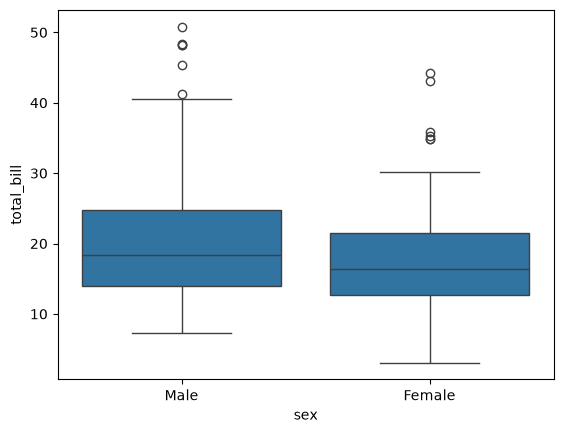

남성 정규성 p-value: 1.0274536685915797e-07
여성 정규성 p-value: 4.211812241575293e-05
Levene 통계량: 1.631715567905501
Levene p-value: 0.20269005267784007
사용한 검정: Student 독립표본 t-test
t 통계량: 2.2777940289803134
p-value: 0.023611666846859423
귀무가설을 기각한다.
남성과 여성 고객의 평균 결제금액에는 통계적으로 유의한 차이가 있다.
Cohen's d: 0.30443873648074676


In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats


# 1. 데이터 불러오기
tips = sns.load_dataset("tips")


# 2. 데이터 확인
print(tips.head())
print(tips.info())


# 3. 집단별 기초통계
summary = tips.groupby(
    "sex",
    observed=True
)["total_bill"].agg(
    ["count", "mean", "std", "median"]
)

print(summary)


# 4. 두 집단 분리
male_bill = tips.loc[
    tips["sex"] == "Male",
    "total_bill"
].dropna()

female_bill = tips.loc[
    tips["sex"] == "Female",
    "total_bill"
].dropna()


# 5. 집단별 평균 확인
print("남성 표본 수:", len(male_bill))
print("여성 표본 수:", len(female_bill))

print("남성 평균:", male_bill.mean())
print("여성 평균:", female_bill.mean())

print(
    "평균 차이:",
    male_bill.mean() - female_bill.mean()
)


# 6. 시각화
sns.boxplot(
    data=tips,
    x="sex",
    y="total_bill"
)

plt.show()


# 7. 정규성 검정
male_shapiro = stats.shapiro(male_bill)
female_shapiro = stats.shapiro(female_bill)

print("남성 정규성 p-value:", male_shapiro.pvalue)
print("여성 정규성 p-value:", female_shapiro.pvalue)


# 8. 등분산성 검정
levene_result = stats.levene(
    male_bill,
    female_bill
)

print("Levene 통계량:", levene_result.statistic)
print("Levene p-value:", levene_result.pvalue)


# 9. 등분산 여부에 따라 검정 선택
alpha = 0.05

if levene_result.pvalue >= alpha:
    equal_var = True
    test_name = "Student 독립표본 t-test"
else:
    equal_var = False
    test_name = "Welch 독립표본 t-test"


# 10. 독립표본 t-test
result = stats.ttest_ind(
    male_bill,
    female_bill,
    equal_var=equal_var,
    alternative="two-sided"
)

print("사용한 검정:", test_name)
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)


# 11. 검정 결과 해석
if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "남성과 여성 고객의 평균 결제금액에는 "
        "통계적으로 유의한 차이가 있다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "남성과 여성 고객의 평균 결제금액이 "
        "다르다고 볼 충분한 근거가 없다."
    )


# 12. Cohen's d 계산
n1 = len(male_bill)
n2 = len(female_bill)

var1 = male_bill.var(ddof=1)
var2 = female_bill.var(ddof=1)

pooled_variance = (
    ((n1 - 1) * var1)
    + ((n2 - 1) * var2)
) / (n1 + n2 - 2)

pooled_std = np.sqrt(pooled_variance)

cohens_d = (
    male_bill.mean()
    - female_bill.mean()
) / pooled_std

print("Cohen's d:", cohens_d)

In [89]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [90]:
tips['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [91]:
tips.groupby('smoker')['total_bill'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
smoker,,,,
Yes,93,20.756344,9.832154,17.92
No,151,19.188278,8.255582,17.59


In [92]:
# mu1: 흡연자, mu2: 비흡연자
# H0: mu1 = mu2 (흡연자와 비흡연자의 평균 결제 금액은 같다)
# H1: mu1 != m2 (흡연자와 비흡연자의 평균 결제 금액은 다르다)

In [95]:
smoker = tips.loc[tips['smoker']=='Yes', 'total_bill']
nonsmoker = tips.loc[tips['smoker']=='No', 'total_bill']

In [96]:
len(smoker), len(nonsmoker)

(93, 151)

In [ ]:
result = stats.ttest_ind(smoker, nonsmoker, )

In [99]:
# 등분산 검정
# H0: 두 집단의 분산은 같다
# h1: 두 집단의 분산은 다르다

lev = stats.levene(smoker, nonsmoker)

if lev.pvalue < 0.05:
    print('H0 기각: 두 집단의 분산은 통계적으로 유의미하게 차이가 있다.')
else:
    print('H0를 기각 할 수 없다. 따라서 두 집단의 분산은 다르다고 할 근거가 부족하다')

H0 기각: 두 집단의 분산은 통계적으로 유의미하게 차이가 있다.


In [98]:
stats.levene(smoker, nonsmoker)

LeveneResult(statistic=np.float64(4.053727631032653), pvalue=np.float64(0.04518116818962142))

In [100]:
# 정규성 확인: shapiro
# H0: 데이터가 정규분포를 따른다
# H1: 데이터가 정규분포를 따르지 않는다

In [101]:
stats.shapiro(smoker)

ShapiroResult(statistic=np.float64(0.9367441211736873), pvalue=np.float64(0.0002166644188825324))

In [102]:
stats.shapiro(nonsmoker)

ShapiroResult(statistic=np.float64(0.9045338652021683), pvalue=np.float64(2.2108584744714854e-08))

In [103]:
# 정규분포는 따르지 않는다. 또한 두 집단의 분산도 같지 않다

In [104]:
stats.ttest_ind(smoker, nonsmoker, equal_var=False, alternative="two-sided")

TtestResult(statistic=np.float64(1.2842515757360153), pvalue=np.float64(0.20080519917308057), df=np.float64(169.625891615264))

In [ ]:
# 귀무가설을 기각하지 못한다. 두 집단의 평균 결제 금액은 통계적으로 유의미하게 다르지 않다

In [108]:
smoker_tip = tips.loc[
    tips["smoker"] == "Yes",
    "tip"
].dropna()

non_smoker_tip = tips.loc[
    tips["smoker"] == "No",
    "tip"
].dropna()

levene_result = stats.levene(
    smoker_tip,
    non_smoker_tip
)

if levene_result.pvalue >= 0.05:
    equal_var = True
else:
    equal_var = False

print(equal_var)

result = stats.ttest_ind(
    smoker_tip,
    non_smoker_tip,
    equal_var=equal_var,
    alternative="two-sided"
)

print("흡연자 평균 팁:", smoker_tip.mean())
print("비흡연자 평균 팁:", non_smoker_tip.mean())
print("Levene p-value:", levene_result.pvalue)
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

True
흡연자 평균 팁: 3.008709677419355
비흡연자 평균 팁: 2.9918543046357615
Levene p-value: 0.8862366542563253
t 통계량: 0.09222805186888201
p-value: 0.9265931522244977


In [107]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("흡연자와 비흡연자의 평균 팁 금액은 다르다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "흡연자와 비흡연자의 평균 팁 금액이 "
        "다르다고 볼 근거가 부족하다."
    )

귀무가설을 기각하지 못한다.
흡연자와 비흡연자의 평균 팁 금액이 다르다고 볼 근거가 부족하다.


In [110]:
tips.time.value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [114]:
tips.groupby('time')['total_bill'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
time,,,,
Lunch,68,17.168676,7.713882,15.965
Dinner,176,20.797159,9.142029,18.390


In [112]:
dinner = tips.loc[tips['time'] == 'Dinner', 'total_bill']
dinner

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 176, dtype: float64

In [113]:
lunch = tips.loc[tips['time'] == 'Lunch', 'total_bill']
lunch

77     27.20
78     22.76
79     17.29
80     19.44
81     16.66
       ...  
222     8.58
223    15.98
224    13.42
225    16.27
226    10.09
Name: total_bill, Length: 68, dtype: float64

In [ ]:
# 정규성 검정
# H0: 데이터는 정규분포를 따른다
# H1: 데이터는 정규분포를 따르지 않는다

stats.shapiro(dinner), stats.shapiro(lunch)
# 점심/저녁 pvalue가 모두 0.05보다 작다. 따라서 두 집단의 데이터는 정규분포를 따르지 않는다.

(ShapiroResult(statistic=np.float64(0.9328960137022453), pvalue=np.float64(2.6869861734145505e-07)),
 ShapiroResult(statistic=np.float64(0.8687172285102468), pvalue=np.float64(3.64052067234852e-06)))

In [ ]:
# 등분산 검정
# H0: 두 집단의 분산은 같다
# H1: 두 집단의 분산은 다르다

stats.levene(lunch, dinner)
# pvalue는 0.1로 0.05보다 크다. 따라서 두 집단의 분산은 같다

LeveneResult(statistic=np.float64(2.6906995489829337), pvalue=np.float64(0.10223461077262591))

In [121]:
# mu1 = 점심 결제금액 평균
# mu2 = 저녁 결제금액 평균
# H0: mu1 = mu2 (점심과 저녁의 평균 결제금액은 같다)
# H1: mu1 != mu2 (점심과 저녁의 평균 결제금액은 다르다)

# 두 집단의 분산이 같으므로 equal_var=true
result = stats.ttest_ind(lunch, dinner, equal_var=True, alternative="two-sided")
result.pvalue

# pvalue가 0.0041로 0.05보다 작으므로 H0기각. 따라서 점심과 저녁의 평균 결제금액은 다르다. 통계적으로 유의미하게 차이가 있다

np.float64(0.004104621407595672)

In [123]:
lunch_bill = tips.loc[
    tips["time"] == "Lunch",
    "total_bill"
].dropna()

dinner_bill = tips.loc[
    tips["time"] == "Dinner",
    "total_bill"
].dropna()

levene_result = stats.levene(
    lunch_bill,
    dinner_bill
)

equal_var = (
    levene_result.pvalue >= 0.05
)
print(equal_var)

result = stats.ttest_ind(
    lunch_bill,
    dinner_bill,
    equal_var=equal_var,
    alternative="two-sided"
)

print("점심 평균:", lunch_bill.mean())
print("저녁 평균:", dinner_bill.mean())
print("등분산 검정 p-value:", levene_result.pvalue)
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("점심과 저녁의 평균 팁 금액은 다르다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "점심과 저녁의 평균 팁 금액이 "
        "다르다고 볼 근거가 부족하다."
    )

True
점심 평균: 17.168676470588235
저녁 평균: 20.79715909090909
등분산 검정 p-value: 0.10223461077262591
t 통계량: -2.8976375218366424
p-value: 0.004104621407595672
귀무가설을 기각한다.
점심과 저녁의 평균 팁 금액은 다르다.


In [124]:
method_a = np.array([
    72, 75, 78, 74, 77,
    80, 76, 79, 73, 81
])

method_b = np.array([
    68, 70, 74, 69, 72,
    71, 73, 67, 75, 70
])

In [125]:
method_a.mean(), method_b.mean()

(np.float64(76.5), np.float64(70.9))

In [ ]:
# 둘 다 pvalue가 0.05보다 크다. 따라서 두 집단의 데이터 모두 정규분포를 따르지 않는다.
stats.shapiro(method_a), stats.shapiro(method_b)

(ShapiroResult(statistic=np.float64(0.9701646110856056), pvalue=np.float64(0.8923673061902978)),
 ShapiroResult(statistic=np.float64(0.9752339025839644), pvalue=np.float64(0.9346854448707653)))

In [ ]:
# pvalue가 0.54로 0.05보다 크다. 따라서 두 집단의 분산은 같다
stats.levene(method_a, method_b)

LeveneResult(statistic=np.float64(0.3749999999999998), pvalue=np.float64(0.5479501508336089))

In [131]:
# 두 집단의 분산이 같으므로 equal_var=True
# H0: 학습방법 A와 B의 평균 점수는 같다
# H1: 학습방법 A와 B의 평균 점수는 다르다

stats.ttest_ind(method_a, method_b, equal_var=True, alternative="two-sided")
# pvalue가 0.00032로 0.05보다 작으므로 H0 기각. 따라서 학습방법 A와 B의 평균 점수는 다르다. 통계적으로 유의미하게 다르다

TtestResult(statistic=np.float64(4.436440957366703), pvalue=np.float64(0.0003187250412675816), df=np.float64(18.0))

In [133]:
print("A 평균:", method_a.mean())
print("B 평균:", method_b.mean())

levene_result = stats.levene(
    method_a,
    method_b
)

equal_var = (
    levene_result.pvalue >= 0.05
)

print(equal_var)

result = stats.ttest_ind(
    method_a,
    method_b,
    equal_var=equal_var,
    alternative="two-sided"
)

print("Levene p-value:", levene_result.pvalue)
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

alpha = 0.05

if result.pvalue < alpha:
    print("두 학습 방법의 평균 점수는 유의하게 다르다.")
else:
    print(
        "두 학습 방법의 평균 점수가 다르다고 "
        "볼 충분한 근거가 없다."
    )

A 평균: 76.5
B 평균: 70.9
True
Levene p-value: 0.5479501508336089
t 통계량: 4.436440957366703
p-value: 0.0003187250412675816
두 학습 방법의 평균 점수는 유의하게 다르다.


In [136]:
from scipy import stats

In [137]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [142]:
flights.groupby('month')['passengers'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
month,,,,
Jan,12,241.750000,101.032960,223.0
Feb,12,235.000000,89.619397,214.5
Mar,12,270.166667,100.559194,251.5
Apr,12,267.083333,107.374839,252.0
May,12,271.833333,114.739890,252.0
Jun,12,311.666667,134.219856,289.5
Jul,12,351.333333,156.827255,333.0
Aug,12,351.083333,155.783333,320.0
Sep,12,302.416667,123.954140,285.5


In [143]:
flights['month'].value_counts()

month
Jan    12
Feb    12
Mar    12
Apr    12
May    12
Jun    12
Jul    12
Aug    12
Sep    12
Oct    12
Nov    12
Dec    12
Name: count, dtype: int64

In [144]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [147]:
jan = flights.loc[flights['month']=='Jan', ['year', 'passengers']]
feb = flights.loc[flights['month']=='Feb', ['year', 'passengers']]

In [160]:
jan['passengers'].values

array([112, 115, 145, 171, 196, 204, 242, 284, 315, 340, 360, 417])

In [165]:
paired = pd.merge(jan,feb, on='year')
paired

,year,passengers_x,passengers_y
0,1949,112,118
1,1950,115,126
2,1951,145,150
3,1952,171,180
4,1953,196,196
5,1954,204,188
6,1955,242,233
7,1956,284,277
8,1957,315,301
9,1958,340,318


In [167]:
paired.rename(columns={'passengers_x':'Jan', 'passengers_y':'Feb'}, inplace=True)

In [169]:
paired['difference'] = paired['Feb'] - paired['Jan']
paired

,year,Jan,Feb,difference
0,1949,112,118,6
1,1950,115,126,11
2,1951,145,150,5
3,1952,171,180,9
4,1953,196,196,0
5,1954,204,188,-16
6,1955,242,233,-9
7,1956,284,277,-7
8,1957,315,301,-14
9,1958,340,318,-22


<Axes: >

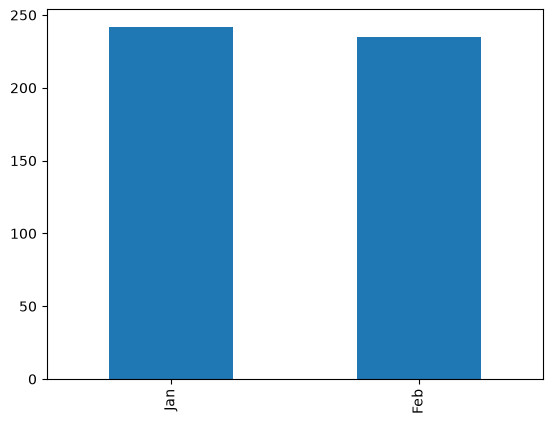

In [173]:
paired[['Jan', 'Feb']].mean().plot(kind='bar')

<Axes: xlabel='difference', ylabel='Count'>

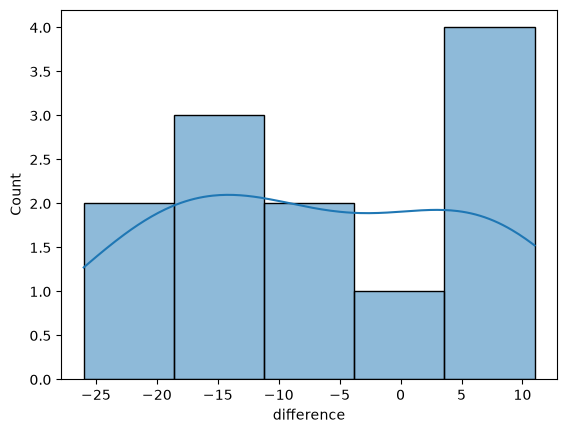

In [175]:
sns.histplot(paired['difference'], kde=True)

<Axes: xlabel='difference'>

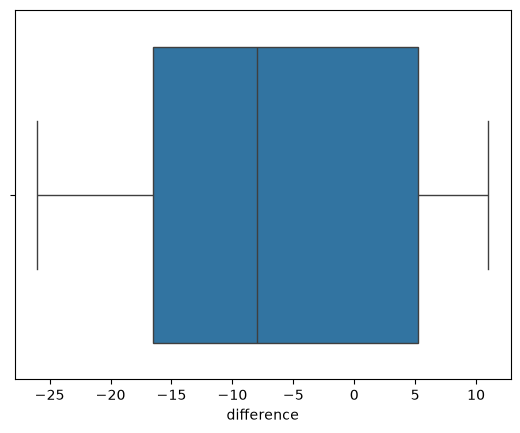

In [176]:
sns.boxplot(x=paired['difference'])

In [179]:
# pvalue가 0.47정도로 0.05보다 크므로, 정규성을 만족한다
result = stats.shapiro(paired['difference'])

alpha = 0.05

if result.pvalue < alpha:
    print("차이값의 정규성을 기각한다.")
else:
    print("차이값의 정규성을 기각하지 못한다.")

차이값의 정규성을 기각하지 못한다.


In [181]:
# pvalue가 0.093정도로 0.05보다 크므로 H0를 기각할 수 없다. Jan과 Feb의 평균 고객 수는 차이가 있다고 할 근거가 부족하다.
result = stats.ttest_rel(paired['Jan'], paired['Feb'], alternative='two-sided')

alpha = 0.05

print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "같은 연도에서 1월과 2월의 "
        "평균 승객 수에는 유의한 차이가 있다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "같은 연도에서 1월과 2월의 "
        "평균 승객 수가 다르다고 볼 "
        "충분한 근거가 없다."
    )

t 통계량: 1.836988454391655
p-value: 0.09335550148616216
귀무가설을 기각하지 못한다.
같은 연도에서 1월과 2월의 평균 승객 수가 다르다고 볼 충분한 근거가 없다.


In [182]:
stats.ttest_1samp(paired['difference'], 0, alternative='two-sided')

TtestResult(statistic=np.float64(-1.836988454391655), pvalue=np.float64(0.09335550148616216), df=np.int64(11))

In [183]:
result.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(-1.3375031060217264), high=np.float64(14.837503106021726))

    year  passengers_jan  passengers_feb  difference
0   1949             112             118           6
1   1950             115             126          11
2   1951             145             150           5
3   1952             171             180           9
4   1953             196             196           0
5   1954             204             188         -16
6   1955             242             233          -9
7   1956             284             277          -7
8   1957             315             301         -14
9   1958             340             318         -22
10  1959             360             342         -18
11  1960             417             391         -26
1월 평균: 241.75
2월 평균: 235.0
평균 차이: -6.75


c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

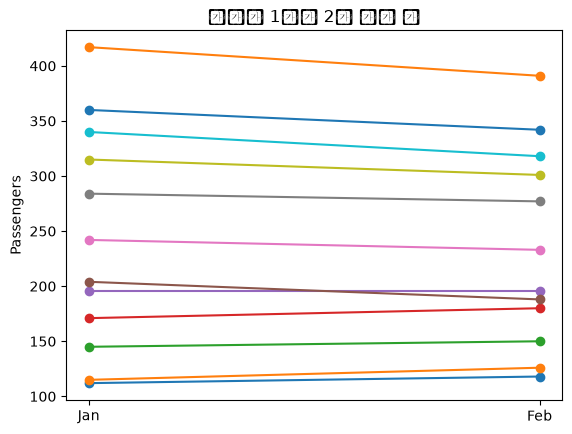

c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

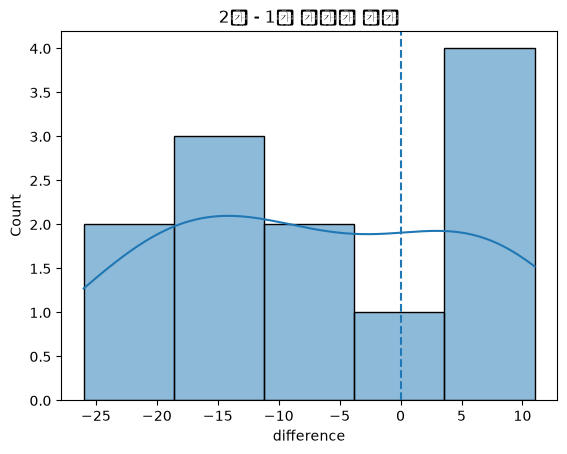

Shapiro 통계량: 0.9378836847705214
Shapiro p-value: 0.47115216055931236
t 통계량: -1.836988454391655
p-value: 0.09335550148616216
귀무가설을 기각하지 못한다.
같은 연도에서 1월과 2월의 평균 승객 수가 다르다고 볼 충분한 근거가 없다.
차이값 일표본 검정:
TtestResult(statistic=np.float64(-1.836988454391655), pvalue=np.float64(0.09335550148616216), df=np.int64(11))
Cohen's dz: -0.5302928893206283
평균 차이의 95% 신뢰구간: -14.837503106021728 1.3375031060217282


In [184]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats


# 1. 데이터 불러오기
flights = sns.load_dataset("flights")


# 2. 1월과 2월 데이터 추출
jan = flights.loc[
    flights["month"] == "Jan",
    ["year", "passengers"]
].copy()

feb = flights.loc[
    flights["month"] == "Feb",
    ["year", "passengers"]
].copy()


# 3. 연도를 기준으로 짝짓기
paired = pd.merge(
    jan,
    feb,
    on="year",
    suffixes=("_jan", "_feb")
)


# 4. 차이값 계산
paired["difference"] = (
    paired["passengers_feb"]
    - paired["passengers_jan"]
)


# 5. 데이터 확인
print(paired)

print(
    "1월 평균:",
    paired["passengers_jan"].mean()
)

print(
    "2월 평균:",
    paired["passengers_feb"].mean()
)

print(
    "평균 차이:",
    paired["difference"].mean()
)


# 6. 대응 관계 시각화
for _, row in paired.iterrows():
    plt.plot(
        ["Jan", "Feb"],
        [
            row["passengers_jan"],
            row["passengers_feb"]
        ],
        marker="o"
    )

plt.ylabel("Passengers")
plt.title("연도별 1월과 2월 승객 수")
plt.show()


# 7. 차이값 분포 확인
sns.histplot(
    paired["difference"],
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("2월 - 1월 차이값 분포")
plt.show()


# 8. 차이값 정규성 검정
shapiro_result = stats.shapiro(
    paired["difference"]
)

print(
    "Shapiro 통계량:",
    shapiro_result.statistic
)

print(
    "Shapiro p-value:",
    shapiro_result.pvalue
)


# 9. 대응표본 t-test
result = stats.ttest_rel(
    paired["passengers_feb"],
    paired["passengers_jan"],
    alternative="two-sided"
)

print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)


# 10. 검정 결과 해석
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "같은 연도에서 1월과 2월의 "
        "평균 승객 수에는 유의한 차이가 있다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "같은 연도에서 1월과 2월의 "
        "평균 승객 수가 다르다고 볼 "
        "충분한 근거가 없다."
    )


# 11. 차이값에 대한 일표본 t-test
difference_result = stats.ttest_1samp(
    paired["difference"],
    popmean=0
)

print("차이값 일표본 검정:")
print(difference_result)


# 12. 효과크기
cohens_dz = (
    paired["difference"].mean()
    / paired["difference"].std(ddof=1)
)

print("Cohen's dz:", cohens_dz)


# 13. 평균 차이의 95% 신뢰구간
difference = paired["difference"]

n = difference.count()

standard_error = stats.sem(
    difference
)

critical_t = stats.t.ppf(
    0.975,
    df=n - 1
)

margin_error = (
    critical_t * standard_error
)

lower = (
    difference.mean() - margin_error
)

upper = (
    difference.mean() + margin_error
)

print(
    "평균 차이의 95% 신뢰구간:",
    lower,
    upper
)

In [185]:
before = np.array([
    65, 70, 72, 68, 75,
    78, 74, 69, 71, 73
])

after = np.array([
    70, 74, 75, 72, 79,
    80, 78, 73, 74, 77
])

In [187]:
diff = after - before
diff

array([5, 4, 3, 4, 4, 2, 4, 4, 3, 4])

In [189]:
# pvalue는 0.045정도로 0.05보다 작으므로, H0 기각. 따라서 데이터들이 정규분포를 따른다고 할 수 없다
stats.shapiro(diff)

ShapiroResult(statistic=np.float64(0.840621887677894), pvalue=np.float64(0.04488770617062266))

In [194]:
# d= after-before
# H0: d <= 0
# H1: d > 0

print(stats.ttest_1samp(diff, 0, alternative='greater'))
print(stats.ttest_rel(after, before, alternative='greater'))
# pvalue가 매우 작으므로, H0 기각. 따라서 after와 before의 차이는 0보다 크다

TtestResult(statistic=np.float64(14.212093672551452), pvalue=np.float64(9.004156615213933e-08), df=np.int64(9))
TtestResult(statistic=np.float64(14.212093672551452), pvalue=np.float64(9.004156615213933e-08), df=np.int64(9))


In [193]:
result = stats.ttest_rel(
    after,
    before,
    alternative="greater"
)

print("교육 전 평균:", before.mean())
print("교육 후 평균:", after.mean())
print("평균 변화량:", (after - before).mean())
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "교육 후 평균 점수가 "
        "교육 전보다 유의하게 높아졌다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "교육 후 평균 점수가 높아졌다고 "
        "볼 충분한 근거가 없다."
    )

교육 전 평균: 71.5
교육 후 평균: 75.2
평균 변화량: 3.7
t 통계량: 14.212093672551452
p-value: 9.004156615213933e-08
귀무가설을 기각한다.
교육 후 평균 점수가 교육 전보다 유의하게 높아졌다.


In [195]:
stats.wilcoxon(
    after,
    before,
    alternative='greater'
)

WilcoxonResult(statistic=np.float64(55.0), pvalue=np.float64(0.0009765625))

In [199]:
print(f'{result.pvalue:0.8f}')

0.00000009


In [200]:
blood_pressure = pd.DataFrame({
    "patient_id": [
        "P01", "P02", "P03", "P04",
        "P05", "P06", "P07", "P08"
    ],
    "before": [
        150, 145, 160, 155,
        148, 152, 158, 147
    ],
    "after": [
        142, 139, 151, 149,
        143, 146, 150, 141
    ]
})

In [ ]:
# 치료 후 혈압이 치료 전보다 낮아졌다고 할 수 있는지 검정하세요.
# d = after - before
# H0: d >= 0 (치료 후 혈압이 치료 전보다 크거나 같다)
# H1: d < 0 (치료 후 혈압이 치료 전보다 작다)
# H0: after >= before
# H1: after < before

print(stats.ttest_rel(blood_pressure['after'], blood_pressure['before'], alternative='less'))
print(stats.ttest_1samp(blood_pressure['after']-blood_pressure['before'], 0, alternative='less'))
# pvalue가 매우 작으므로, H0 기각. 따라서 치료 후 혈압이 치료전보다 작다. 즉 치료 후 효과가 있다.

TtestResult(statistic=np.float64(-13.74772708486752), pvalue=np.float64(1.2704952772255126e-06), df=np.int64(7))
TtestResult(statistic=np.float64(-13.74772708486752), pvalue=np.float64(1.2704952772255126e-06), df=np.int64(7))


In [203]:
blood_pressure

,patient_id,before,after
0,P01,150,142
1,P02,145,139
2,P03,160,151
3,P04,155,149
4,P05,148,143
5,P06,152,146
6,P07,158,150
7,P08,147,141


In [207]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [208]:
tips = sns.load_dataset("tips")

In [209]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [210]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [214]:
tips[['day', 'total_bill']]

,day,total_bill
0,Sun,16.99
1,Sun,10.34
2,Sun,21.01
3,Sun,23.68
4,Sun,24.59
...,...,...
239,Sat,29.03
240,Sat,27.18
241,Sat,22.67
242,Sat,17.82


In [216]:
tips.groupby('day')['total_bill'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
day,,,,
Thur,62,17.682742,7.886170,16.20
Fri,19,17.151579,8.302660,15.38
Sat,87,20.441379,9.480419,18.24
Sun,76,21.410000,8.832122,19.63


In [217]:
tips['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

<Axes: xlabel='day', ylabel='total_bill'>

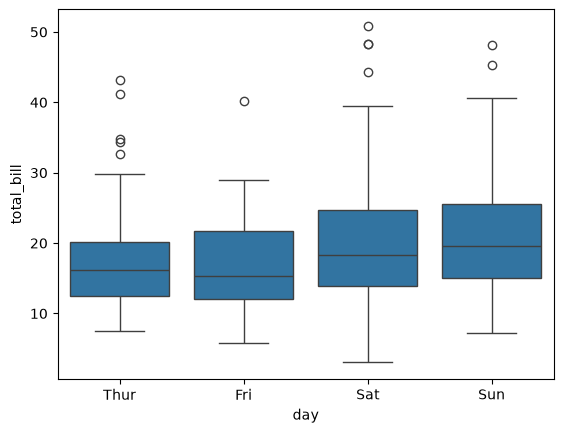

In [219]:
sns.boxplot(tips, x='day', y='total_bill')

In [221]:
thur_bill = tips.loc[
    tips["day"] == "Thur",
    "total_bill"
].dropna()

fri_bill = tips.loc[
    tips["day"] == "Fri",
    "total_bill"
].dropna()

sat_bill = tips.loc[
    tips["day"] == "Sat",
    "total_bill"
].dropna()

sun_bill = tips.loc[
    tips["day"] == "Sun",
    "total_bill"
].dropna()

In [222]:
stats.shapiro(thur_bill)

ShapiroResult(statistic=np.float64(0.8844888694104517), pvalue=np.float64(2.85715908758707e-05))

In [223]:
groups = {'thur':thur_bill, 'fri':fri_bill, 'sat':sat_bill, 'sun':sun_bill}

In [233]:
groups.keys()

dict_keys(['thur', 'fri', 'sat', 'sun'])

In [235]:
for key, value in groups.items():
    print(f"{key}: {stats.shapiro(value).pvalue}")

thur: 2.85715908758707e-05
fri: 0.04085649671549424
sat: 7.991754612612711e-06
sun: 0.0035657960627037966


In [236]:
alpha = 0.05

for name, values in groups.items():
    result = stats.shapiro(values)

    if result.pvalue < alpha:
        print(name, ": 정규성 기각")
    else:
        print(name, ": 정규성을 기각하지 못함")

thur : 정규성 기각
fri : 정규성 기각
sat : 정규성 기각
sun : 정규성 기각


In [238]:
levene_result = stats.levene(thur_bill, fri_bill, sat_bill, sun_bill)

if levene_result.pvalue < 0.05:
    print("등분산 가정을 만족하지 않는다.")
else:
    print("등분산 가정을 기각하지 못한다.")

등분산 가정을 기각하지 못한다.


In [241]:
# pvalue가 0.04정도로 0.05보다 작으므로 H0 기각. 따라서 적어도 1개는 평균이 다르다
anova_result = stats.f_oneway(thur_bill, fri_bill, sat_bill, sun_bill)

alpha = 0.05

print("F 통계량:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

if anova_result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "요일별 평균 총 결제금액 중 "
        "적어도 하나는 다르다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "요일별 평균 총 결제금액이 "
        "다르다고 볼 충분한 근거가 없다."
    )

F 통계량: 2.767479443286335
p-value: 0.04245383328952
귀무가설을 기각한다.
요일별 평균 총 결제금액 중 적어도 하나는 다르다.


In [242]:
for key, value in groups.items():
    print(f'{key}: {len(value)}')

thur: 62
fri: 19
sat: 87
sun: 76


In [243]:
stats.f_oneway(thur_bill, fri_bill, sat_bill, sun_bill)

F_onewayResult(statistic=np.float64(2.767479443286335), pvalue=np.float64(0.04245383328952))

In [ ]:
pairwise_tukeyhsd

In [244]:
tukey_result = pairwise_tukeyhsd(
    endog=tips["total_bill"],
    groups=tips["day"],
    alpha=0.05
)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   Fri    Sat   3.2898 0.4541 -2.4799  9.0595  False
   Fri    Sun   4.2584 0.2371 -1.5856 10.1025  False
   Fri   Thur   0.5312 0.9957 -5.4434  6.5057  False
   Sat    Sun   0.9686 0.8968 -2.6088   4.546  False
   Sat   Thur  -2.7586 0.2374 -6.5455  1.0282  False
   Sun   Thur  -3.7273 0.0668 -7.6264  0.1719  False
----------------------------------------------------


In [245]:
tukey_result.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Fri,Sat,3.2898,0.4541,-2.4799,9.0595,False
Fri,Sun,4.2584,0.2371,-1.5856,10.1025,False
Fri,Thur,0.5312,0.9957,-5.4434,6.5057,False
Sat,Sun,0.9686,0.8968,-2.6088,4.546,False
Sat,Thur,-2.7586,0.2374,-6.5455,1.0282,False
Sun,Thur,-3.7273,0.0668,-7.6264,0.1719,False


In [2]:
method_a = np.array([
    72, 75, 78, 74, 77,
    76, 79, 73
])

method_b = np.array([
    68, 70, 71, 69, 72,
    74, 67, 73
])

method_c = np.array([
    80, 82, 79, 85, 81,
    83, 84, 78
])

In [3]:
result = stats.f_oneway(method_a, method_b, method_c)
result

F_onewayResult(statistic=np.float64(40.44444444444442), pvalue=np.float64(6.280163049163939e-08))

In [ ]:
# pvalue가 1.0으로 0.05보다 크므로 귀무가설 기각. 따라서 3 집단의 분산은 다르다
stats.levene(method_a, method_b, method_c)

LeveneResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))

In [5]:
if result.pvalue < 0.05:
    print(
        "세 교육방법의 평균 점수 중 "
        "적어도 하나는 다르다."
    )
else:
    print(
        "세 교육방법의 평균 점수가 "
        "다르다고 볼 근거가 부족하다."
    )

세 교육방법의 평균 점수 중 적어도 하나는 다르다.


In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [7]:
method_a

array([72, 75, 78, 74, 77, 76, 79, 73])

In [20]:
a = pd.DataFrame(method_a, columns=['score'])
a

,score
0,72
1,75
2,78
3,74
4,77
5,76
6,79
7,73


In [21]:
a['method'] = "A"

In [22]:
a

,score,method
0,72,A
1,75,A
2,78,A
3,74,A
4,77,A
5,76,A
6,79,A
7,73,A


In [25]:
b = pd.DataFrame(method_b, columns=['score'])
b['method'] = 'B'
b

,score,method
0,68,B
1,70,B
2,71,B
3,69,B
4,72,B
5,74,B
6,67,B
7,73,B


In [26]:
c = pd.DataFrame(method_b, columns=['score'])
c['method'] = "C"
c

,score,method
0,68,C
1,70,C
2,71,C
3,69,C
4,72,C
5,74,C
6,67,C
7,73,C


In [28]:
df = pd.concat([a,b,c], axis=0)
df

,score,method
0,72,A
1,75,A
2,78,A
3,74,A
4,77,A
5,76,A
6,79,A
7,73,A
0,68,B
1,70,B


In [29]:
tukey_result = pairwise_tukeyhsd(df["score"], df["method"], 0.05)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -5.0 0.0015 -8.0871 -1.9129   True
     A      C     -5.0 0.0015 -8.0871 -1.9129   True
     B      C      0.0    1.0 -3.0871  3.0871  False
----------------------------------------------------


In [34]:
a = [1,2,3,4,5,6,7,8,9]
print(np.var(a))
print(np.sqrt(np.var(a)))

6.666666666666667
2.581988897471611


In [ ]:
print(np.var(a, ddof=1))
print(np.sqrt(np.var(a, ddof=1)))

7.5
2.7386127875258306


: 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [30]:
s = pd.Series([1,2,3,4,5,6,7,8,9])
s.var()

np.float64(7.5)

In [38]:
np.sqrt(np.sum((s - s.mean())**2)/(len(s)-1))

np.float64(2.7386127875258306)

In [7]:
s.var()

np.float64(7.5)

In [8]:
b = np.array([34,25,76,13,78,72,89,12,34,57])

In [10]:
b.mean()

np.float64(49.0)

In [13]:
b-49

array([-15, -24,  27, -36,  29,  23,  40, -37, -15,   8])

In [26]:
rand = np.random.randint(1,100, 50)
rand

array([87, 25, 33, 52, 92, 55, 60, 67, 38,  6, 80,  8, 29, 23, 13, 16,  2,
       35, 80, 56, 60, 47, 33, 58, 35, 78, 53, 67, 72, 94, 79, 34, 26, 44,
       37, 92,  1, 52, 34, 20,  8, 73, 95, 66, 55, 14, 12, 41, 42,  3],
      dtype=int32)

In [29]:
np.sum(rand - rand.mean())

np.float64(-2.842170943040401e-14)

In [27]:
rand.mean()

np.float64(45.64)

In [3]:
from scipy.stats import norm

norm.cdf(-0.8) - norm.cdf(-1)

np.float64(0.05320014465193962)

In [4]:
stats.norm.cdf(2)

np.float64(0.9772498680518208)

In [5]:
1- norm.cdf(2)

np.float64(0.02275013194817921)

In [6]:
norm.sf(2)

np.float64(0.0227501319481792)

In [2]:
class_a = np.array([
    68, 72, 75, 71, 69,
    73, 74, 70, 72, 71
])

class_b = np.array([
    55, 62, 68, 75, 81,
    59, 85, 72, 65, 78
])

In [3]:
class_a.mean(), class_b.mean()

(np.float64(71.5), np.float64(70.0))

In [15]:
class_a.var(ddof=1), class_b.var(ddof=1)

(np.float64(4.722222222222222), np.float64(97.55555555555556))

In [16]:
class_a.std(ddof=1), class_b.std(ddof=1)

(np.float64(2.173067468400883), np.float64(9.877021593352703))

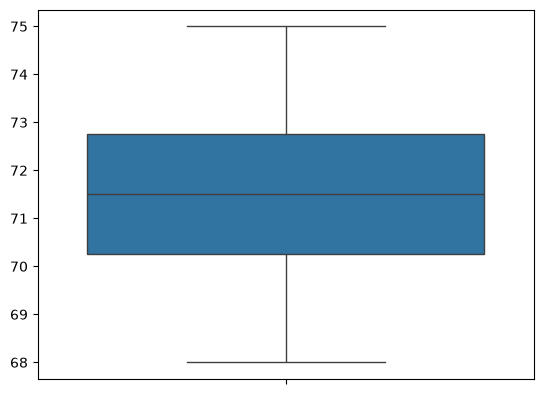

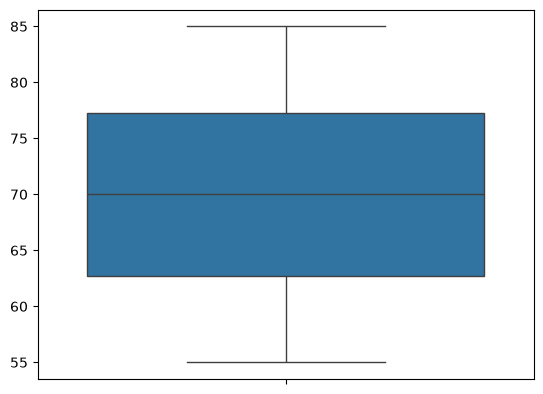

In [20]:
sns.boxplot(class_a)
plt.show()
sns.boxplot(class_b)
plt.show()

In [27]:
a = pd.DataFrame(class_a, columns=['score'])
a['class'] = 'A'
a

,score,class
0,68,A
1,72,A
2,75,A
3,71,A
4,69,A
5,73,A
6,74,A
7,70,A
8,72,A
9,71,A


In [29]:
b = pd.DataFrame(class_b, columns=['score'])
b['class'] = 'B'
b

,score,class
0,55,B
1,62,B
2,68,B
3,75,B
4,81,B
5,59,B
6,85,B
7,72,B
8,65,B
9,78,B


In [33]:
df = pd.concat([a,b], axis=0)
df

,score,class
0,68,A
1,72,A
2,75,A
3,71,A
4,69,A
5,73,A
6,74,A
7,70,A
8,72,A
9,71,A


<Axes: xlabel='class', ylabel='score'>

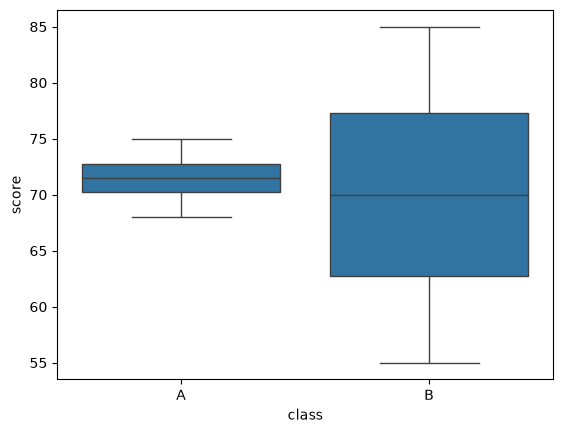

In [34]:
sns.boxplot(df, x='class', y='score')

In [41]:
stats.shapiro(df[df['class'] == 'A']['score'])

ShapiroResult(statistic=np.float64(0.9839820702784123), pvalue=np.float64(0.9828902213611195))

In [42]:
stats.shapiro(df[df['class'] == 'B']['score'])

ShapiroResult(statistic=np.float64(0.975552951315588), pvalue=np.float64(0.9370260229341111))

In [43]:
var_a = class_a.var(ddof=1)
var_b = class_b.var(ddof=1)
var_a, var_b

(np.float64(4.722222222222222), np.float64(97.55555555555556))

In [44]:
f_stat = var_a / var_b
f_stat

np.float64(0.048405466970387244)

In [45]:
df1 = len(class_a) - 1
df2 = len(class_b) - 1

In [46]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [48]:
male = tips.loc[tips['sex']=='Male', 'total_bill']
female = tips.loc[tips['sex']=='Female', 'total_bill']

In [49]:
male.shape, female.shape

((157,), (87,))

In [52]:
tips.groupby('sex')['total_bill'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
sex,,,,
Male,157,20.744076,9.246469,18.35
Female,87,18.056897,8.009209,16.40


In [62]:
plt.rcParams['font.family'] = 'NanumGothic'

Text(0.5, 1.0, '성별 총 결제금액 분포')

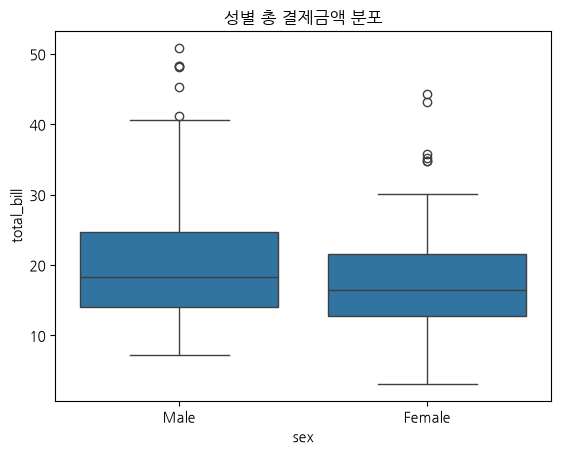

In [63]:
sns.boxplot(tips, x='sex', y='total_bill')
plt.title("성별 총 결제금액 분포")

<Axes: xlabel='total_bill', ylabel='Count'>

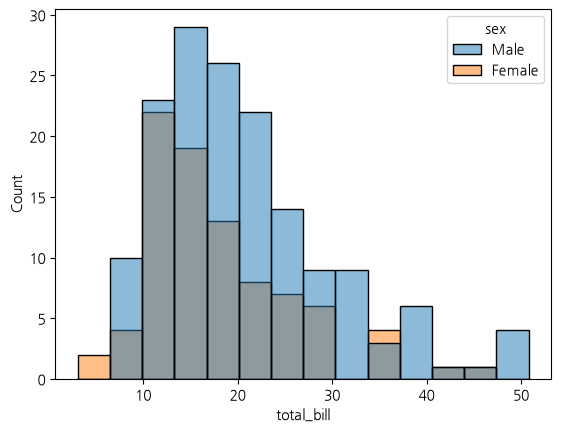

In [69]:
sns.histplot(tips, x='total_bill', hue='sex')

<Axes: >

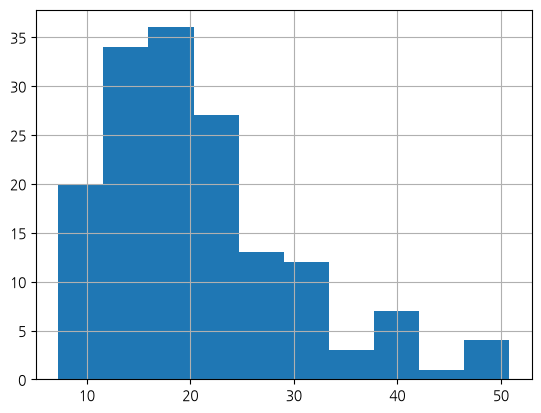

In [73]:
tips.loc[tips['sex']=='Male', 'total_bill'].hist(bins=10)

<Axes: >

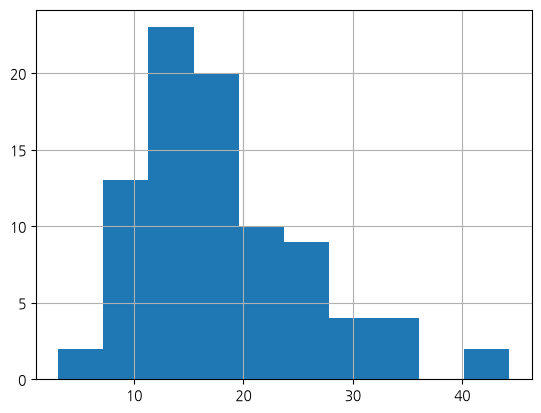

In [74]:
tips.loc[tips['sex']=='Female', 'total_bill'].hist(bins=10)

In [ ]:
stats.shapiro(male) # 정규분포를 따르지 않는다

ShapiroResult(statistic=np.float64(0.9187337722958244), pvalue=np.float64(1.0274536685915797e-07))

In [ ]:
stats.shapiro(female) # 정규분포를 따르지 않는다

ShapiroResult(statistic=np.float64(0.9188766163908312), pvalue=np.float64(4.211812241575293e-05))

In [82]:
stats.levene(male, female) # 0.05보다 크므로 H0기각 실패. 두 집단의 분산은 같다는 귀무가설을 기각할 충분한 근거가 없다

LeveneResult(statistic=np.float64(1.631715567905501), pvalue=np.float64(0.20269005267784007))

In [83]:
if stats.levene(male, female).pvalue < 0.05:
    print("등분산 가정을 기각한다.")
else:
    print("등분산 가정을 기각하지 못한다.")

등분산 가정을 기각하지 못한다.


In [84]:
line_a = np.array([
    499, 501, 500, 502, 498,
    501, 499, 500, 502, 498
])

line_b = np.array([
    493, 505, 497, 508, 491,
    504, 496, 507, 494, 506
])

In [ ]:
stats.shapiro(line_a) # 0.05보다 크므로 귀무가설 기각 실패. 정규분포를 따른다

ShapiroResult(statistic=np.float64(0.9180690908553841), pvalue=np.float64(0.341131529799097))

In [ ]:
stats.shapiro(line_b) # 0.05보다 크므로 귀무가설 기각 실패. 정규분포를 따른다

ShapiroResult(statistic=np.float64(0.8808082645484152), pvalue=np.float64(0.1333106323452975))

In [ ]:
result = stats.levene(line_a, line_b) # pvalue가 매우 작으므로 귀무가설 기각. 두 집단의 분산은 다르다 
result

LeveneResult(statistic=np.float64(49.7025), pvalue=np.float64(1.4119861546690543e-06))

In [93]:
if result.pvalue < 0.05:
    print(
        "두 생산라인의 제품 무게 분산은 "
        "통계적으로 유의하게 다르다."
    )
else:
    print(
        "두 생산라인의 제품 무게 분산이 "
        "다르다고 볼 충분한 근거가 없다."
    )

두 생산라인의 제품 무게 분산은 통계적으로 유의하게 다르다.


In [96]:
smoker = tips.loc[tips['smoker']=='Yes', 'tip']
nonsmoker = tips.loc[tips['smoker']=='No', 'tip']

In [98]:
stats.levene(smoker, nonsmoker) # 0.05보다 크므로 H0기각 실패. 두 집단의 분산은 통계적으로 유의미하게 다르다

LeveneResult(statistic=np.float64(0.02051159105706963), pvalue=np.float64(0.8862366542563253))

In [99]:
smoker.mean(), nonsmoker.mean()

(np.float64(3.008709677419355), np.float64(2.9918543046357615))

In [100]:
smoker.var(ddof=1), nonsmoker.var(ddof=1)

(np.float64(1.964111360448808), np.float64(1.8966525386313469))

In [101]:
rng = np.random.default_rng()
normal_data = rng.normal(loc=70, scale=10, size=50)
normal_data

array([54.72844207, 62.74588227, 62.5720304 , 85.0940009 , 76.79982687,
       76.51178546, 76.5693593 , 62.98308732, 72.27140355, 58.59432252,
       55.19170576, 51.1255748 , 74.28263252, 64.16246365, 58.57649895,
       68.92198694, 71.39142122, 63.66329646, 79.86202626, 77.26157822,
       93.05907122, 59.62998939, 75.43411706, 80.11964615, 63.09738435,
       88.17617759, 70.22890601, 73.12307177, 75.50977294, 71.26278264,
       73.16107105, 80.07495951, 86.83584329, 67.42478311, 68.44526256,
       63.95298735, 75.44291896, 73.31276306, 70.52357696, 87.97568408,
       84.53990643, 50.34509225, 52.5867081 , 79.22098688, 79.6983333 ,
       61.14199078, 66.14368641, 76.08957743, 69.75759505, 80.54181303])

In [110]:
plt.rcParams['axes.unicode_minus'] = False

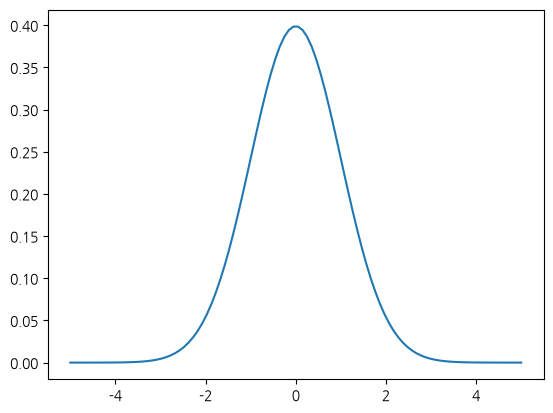

In [111]:
x = np.linspace(-5, 5, 100)
y = stats.norm.pdf(x)
plt.plot(x,y)

In [113]:
result = stats.shapiro(normal_data) # pvalue가 0.75로 0.05보다 크므로, 귀무가설 기각 실패. 데이터가 정규분포를 따르지 않는다는 근거가 충분하지 않다 (정규분포를 따른다)
result

ShapiroResult(statistic=np.float64(0.9845332218003733), pvalue=np.float64(0.7513650563480787))

In [114]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("정규분포를 따른다고 보기 어렵다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "정규분포를 따르지 않는다고 판단할 "
        "충분한 근거가 없다."
    )

귀무가설을 기각하지 못한다.
정규분포를 따르지 않는다고 판단할 충분한 근거가 없다.


In [115]:
skewed_data = rng.exponential(
    scale=10,
    size=50
)

In [116]:
skewed_data

array([7.29508072e+00, 1.11248677e+01, 1.34092714e+01, 3.96998895e+01,
       1.03712427e+00, 2.40462688e+01, 7.97262750e+00, 2.80153549e+01,
       3.07654761e+00, 9.94600544e+00, 1.13587861e+01, 1.39377622e+01,
       8.22964067e+00, 6.64664227e+00, 4.28180440e+00, 5.75068631e-01,
       1.33829737e+01, 6.10529647e+00, 6.89681334e+00, 5.48357923e+00,
       5.68556852e+00, 1.24330536e+01, 5.03119932e+00, 4.37846471e+00,
       3.92711039e+00, 4.75798291e+00, 4.10050976e+00, 2.96478946e+00,
       4.70726003e+00, 4.50222474e+00, 9.85414433e+00, 9.10112754e-01,
       1.22443585e+01, 6.51654657e+00, 3.62734877e-02, 4.22881793e+00,
       1.40932193e+01, 8.50761884e+00, 1.10648606e+01, 4.03054658e+00,
       9.87036527e+00, 1.60293466e+01, 1.92431368e+01, 2.87921253e+00,
       5.82438625e+00, 1.67672923e+01, 2.24299911e+01, 1.39203549e+01,
       1.03663592e+01, 2.56874421e+00])

In [ ]:
stats.shapiro(skewed_data) # pvalue가 매우 작으므로 귀무가설 기각. 데이터가 정규분포를 따른다라고 보기 어렵다

ShapiroResult(statistic=np.float64(0.8478349876438264), pvalue=np.float64(1.3524814799120806e-05))

<Axes: ylabel='Count'>

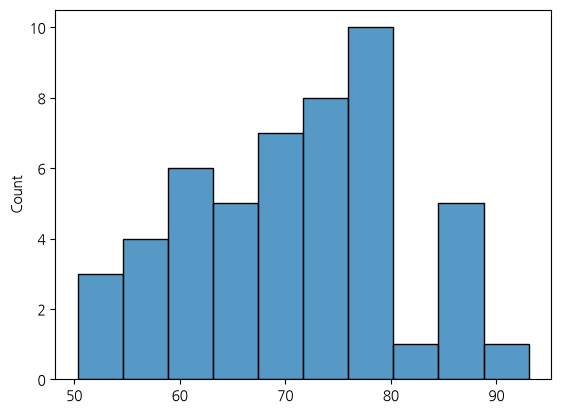

In [119]:
sns.histplot(normal_data, bins=10)

<Axes: ylabel='Count'>

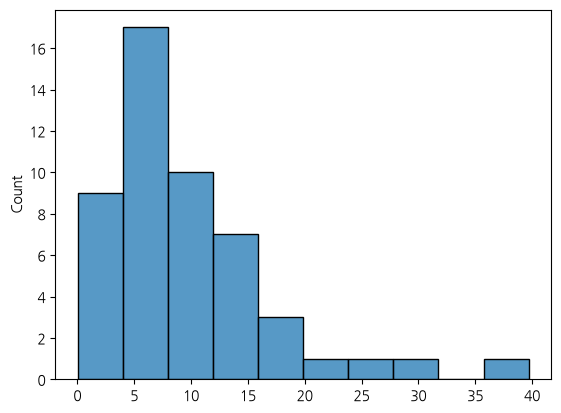

In [120]:
sns.histplot(skewed_data, bins=10)

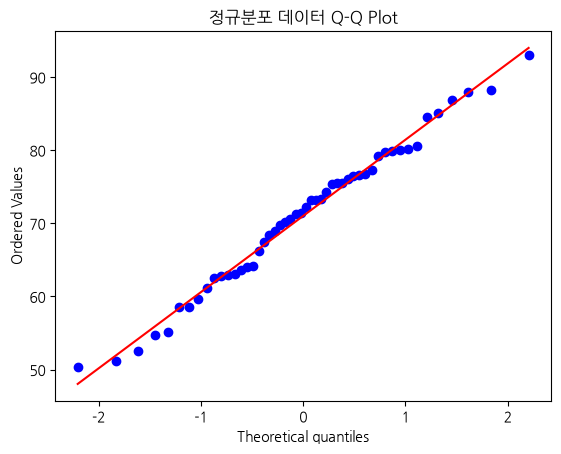

In [121]:
stats.probplot(
    normal_data,
    dist="norm",
    plot=plt
)

plt.title("정규분포 데이터 Q-Q Plot")
plt.show()

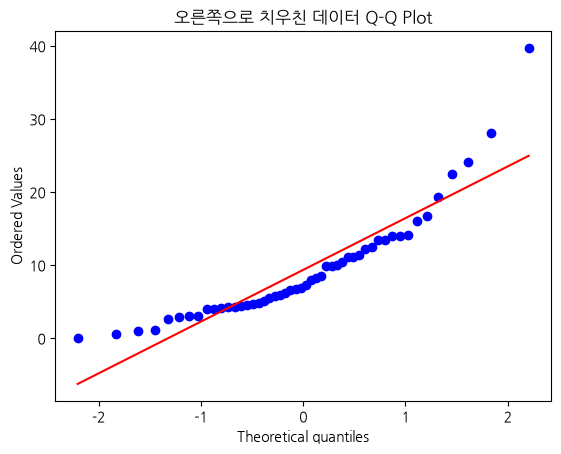

In [122]:
stats.probplot(
    skewed_data,
    dist="norm",
    plot=plt
)

plt.title("오른쪽으로 치우친 데이터 Q-Q Plot")
plt.show()

In [123]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='Count'>

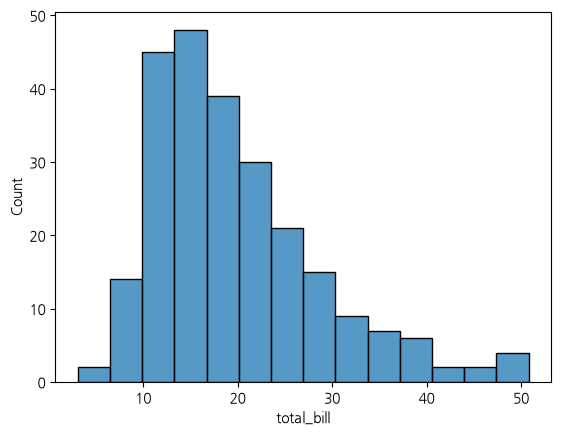

In [125]:
sns.histplot(tips['total_bill'])

In [ ]:
stats.shapiro(tips['total_bill']) # pvalue가 0.05보다 매우 작으므로 귀무가설 기각. 따라서 데이터가 정규분포를 따른다고 보기 어렵다

ShapiroResult(statistic=np.float64(0.9197187941346584), pvalue=np.float64(3.324539186809091e-10))

A반 분산: 4.722222222222222
B반 분산: 97.55555555555556
A반 표준편차: 2.173067468400883
B반 표준편차: 9.877021593352703


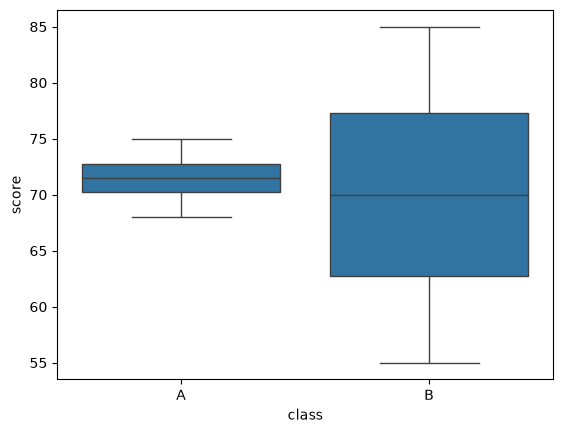

Levene 통계량: 17.347171532846712
Levene p-value: 0.0005817568656980216
등분산 가정을 기각한다.
사용한 equal_var: False
t 통계량: 0.4690299951377803
t-test p-value: 0.6492374866984393
직접 계산한 결과: F_onewayResult(statistic=np.float64(17.347171532846712), pvalue=np.float64(0.0005817568656980216))


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats


# 1. 데이터
class_a = np.array([
    68, 72, 75, 71, 69,
    73, 74, 70, 72, 71
])

class_b = np.array([
    55, 62, 68, 75, 81,
    59, 85, 72, 65, 78
])


# 2. 기초통계
print("A반 분산:", class_a.var(ddof=1))
print("B반 분산:", class_b.var(ddof=1))

print("A반 표준편차:", class_a.std(ddof=1))
print("B반 표준편차:", class_b.std(ddof=1))


# 3. 데이터프레임
score_df = pd.DataFrame({
    "score": np.concatenate([
        class_a,
        class_b
    ]),
    "class": (
        ["A"] * len(class_a)
        + ["B"] * len(class_b)
    )
})


# 4. 시각화
sns.boxplot(
    data=score_df,
    x="class",
    y="score"
)

plt.show()


# 5. Levene 검정
levene_result = stats.levene(
    class_a,
    class_b,
    center="median"
)

print("Levene 통계량:", levene_result.statistic)
print("Levene p-value:", levene_result.pvalue)


# 6. 등분산 여부 판단
alpha = 0.05

if levene_result.pvalue >= alpha:
    equal_var = True
    print("등분산 가정을 기각하지 못한다.")
else:
    equal_var = False
    print("등분산 가정을 기각한다.")


# 7. 독립표본 t-test
t_result = stats.ttest_ind(
    class_a,
    class_b,
    equal_var=equal_var,
    alternative="two-sided"
)

print("사용한 equal_var:", equal_var)
print("t 통계량:", t_result.statistic)
print("t-test p-value:", t_result.pvalue)


# 8. Levene 원리 직접 확인
median_a = np.median(class_a)
median_b = np.median(class_b)

dev_a = np.abs(
    class_a - median_a
)

dev_b = np.abs(
    class_b - median_b
)

manual_result = stats.f_oneway(
    dev_a,
    dev_b
)

print("직접 계산한 결과:", manual_result)

흡연자 표본 수: 93
비흡연자 표본 수: 151
흡연자 평균: 3.008709677419355
비흡연자 평균: 2.9918543046357615
흡연자 중앙값: 3.0
비흡연자 중앙값: 2.74


c:\ajb\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 55137 (\N{HANGUL SYLLABLE HEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\

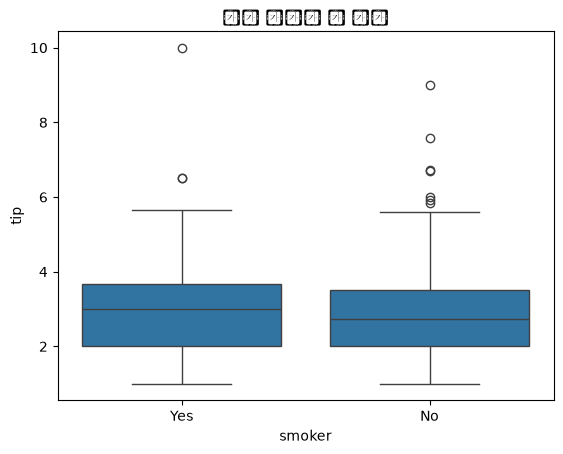

흡연자 Shapiro p-value: 3.612564268702905e-07
비흡연자 Shapiro p-value: 2.0587577501677123e-08
U 통계량: 7163.0
p-value: 0.7919240198382322
귀무가설을 기각하지 못한다.
흡연자와 비흡연자의 팁 분포가 다르다고 볼 충분한 근거가 없다.
우월확률: 0.510076194545325
Rank-biserial correlation: 0.02015238909065009

Welch t-test
t 통계량: 0.09184420123861653
p-value: 0.9269174486592786


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats


# 1. 데이터 불러오기
tips = sns.load_dataset("tips")


# 2. 두 독립 집단 추출
smoker_tip = tips.loc[
    tips["smoker"] == "Yes",
    "tip"
].dropna()

non_smoker_tip = tips.loc[
    tips["smoker"] == "No",
    "tip"
].dropna()


# 3. 기초통계
print("흡연자 표본 수:", len(smoker_tip))
print("비흡연자 표본 수:", len(non_smoker_tip))

print("흡연자 평균:", smoker_tip.mean())
print("비흡연자 평균:", non_smoker_tip.mean())

print("흡연자 중앙값:", smoker_tip.median())
print("비흡연자 중앙값:", non_smoker_tip.median())


# 4. 시각화
sns.boxplot(
    data=tips,
    x="smoker",
    y="tip"
)

plt.title("흡연 여부별 팁 분포")
plt.show()


# 5. 정규성 확인
smoker_shapiro = stats.shapiro(
    smoker_tip
)

non_smoker_shapiro = stats.shapiro(
    non_smoker_tip
)

print(
    "흡연자 Shapiro p-value:",
    smoker_shapiro.pvalue
)

print(
    "비흡연자 Shapiro p-value:",
    non_smoker_shapiro.pvalue
)


# 6. Mann-Whitney U 검정
u_result = stats.mannwhitneyu(
    smoker_tip,
    non_smoker_tip,
    alternative="two-sided",
    method="auto"
)

print("U 통계량:", u_result.statistic)
print("p-value:", u_result.pvalue)


# 7. 검정 결과 해석
alpha = 0.05

if u_result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "흡연자와 비흡연자의 팁 분포에는 "
        "유의한 차이가 있다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "흡연자와 비흡연자의 팁 분포가 "
        "다르다고 볼 충분한 근거가 없다."
    )


# 8. 효과크기
n1 = len(smoker_tip)
n2 = len(non_smoker_tip)

probability_superiority = (
    u_result.statistic / (n1 * n2)
)

rank_biserial = (
    2 * probability_superiority - 1
)

print(
    "우월확률:",
    probability_superiority
)

print(
    "Rank-biserial correlation:",
    rank_biserial
)


# 9. Welch t-test와 비교
t_result = stats.ttest_ind(
    smoker_tip,
    non_smoker_tip,
    equal_var=False,
    alternative="two-sided"
)

print()
print("Welch t-test")
print("t 통계량:", t_result.statistic)
print("p-value:", t_result.pvalue)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

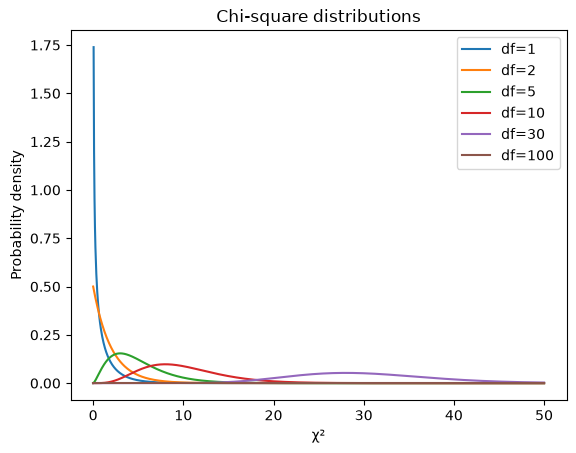

In [9]:
x = np.linspace(0, 50, 1000)

degrees_of_freedom = [1, 2, 5, 10, 30, 100]

for df in degrees_of_freedom:
    y = stats.chi2.pdf(x, df=df)

    plt.plot(
        x,
        y,
        label=f"df={df}"
    )

plt.xlabel("χ²")
plt.ylabel("Probability density")
plt.title("Chi-square distributions")
plt.legend()
plt.show()

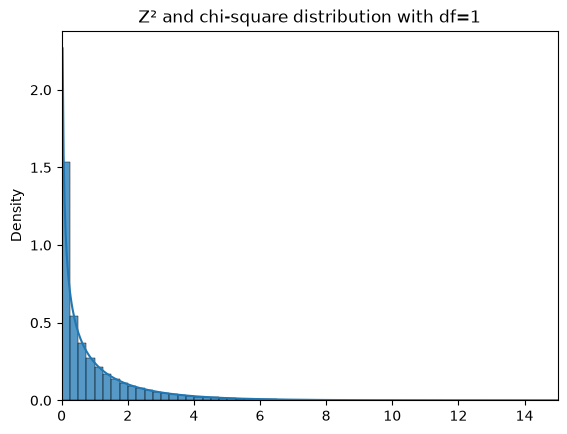

In [17]:
rng = np.random.default_rng(42)

z = rng.normal(
    loc=0,
    scale=1,
    size=100000
)

chi_square_1 = z ** 2

sns.histplot(
    chi_square_1,
    bins=100,
    stat="density"
)

x = np.linspace(0, 15, 500)

plt.plot(
    x,
    stats.chi2.pdf(x, df=1)
)

plt.xlim(0, 15)
plt.title("Z² and chi-square distribution with df=1")
plt.show()

In [22]:
z

array([ 0.30471708, -1.03998411,  0.7504512 , ...,  1.50317659,
       -0.15326604,  0.65459074], shape=(100000,))

In [27]:
z = rng.normal(
    loc=0,
    scale=1,
    size=(100000, 5)
)

chi_square_5 = np.sum(
    z ** 2,
    axis=1
)

In [28]:
chi_square_5

array([14.67354645,  2.91164324,  4.37852158, ...,  0.33438296,
        1.85632297,  2.21131929], shape=(100000,))

In [35]:
z

array([[-1.5745996 ,  2.39088075,  1.79630858, -0.82867115,  1.60139045],
       [-1.15012729, -0.67371945,  0.00959792, -0.87650947,  0.60546808],
       [ 1.1374308 , -1.41937172,  0.11852618, -0.99025882,  0.27476479],
       ...,
       [ 0.01484677,  0.23063262, -0.30917625, -0.07993101,  0.42307471],
       [-0.49215863,  0.19145774,  0.8959213 , -0.36447893,  0.80120343],
       [-0.23685105,  1.07909643, -0.92855179,  0.17397233, -0.31352347]],
      shape=(100000, 5))

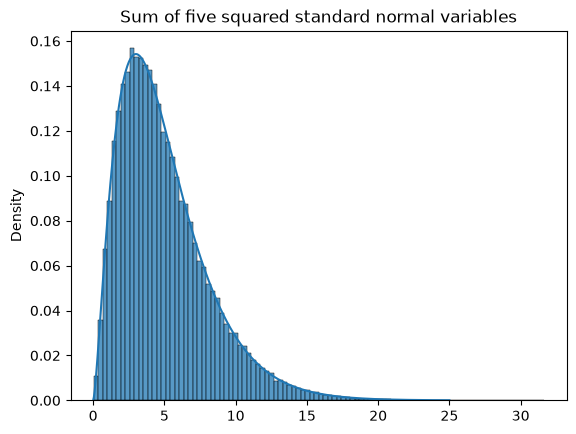

In [16]:
sns.histplot(
    chi_square_5,
    bins=100,
    stat="density"
)

x = np.linspace(0, 25, 500)

plt.plot(
    x,
    stats.chi2.pdf(x, df=5)
)

plt.title("Sum of five squared standard normal variables")
plt.show()

In [36]:
print(
    "표본평균:",
    chi_square_5.mean()
)

print(
    "이론적 평균:",
    5
)

print(
    "표본분산:",
    chi_square_5.var()
)

print(
    "이론적 분산:",
    2 * 5
)

표본평균: 4.999489760839474
이론적 평균: 5
표본분산: 10.039846413933194
이론적 분산: 10


In [37]:
14+18+20+22+24+22

120

In [38]:
observed = np.array([
    14, 18, 20, 22, 24, 22
])

expected = np.array([
    20, 20, 20, 20, 20, 20
])


In [39]:
result = stats.chisquare(
    f_obs=observed,
    f_exp=expected
)

print(
    "χ² 통계량:",
    result.statistic
)

print(
    "p-value:",
    result.pvalue
)

alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "주사위의 눈별 출현확률이 "
        "동일하지 않다고 판단한다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "주사위가 공정하지 않다고 판단할 "
        "충분한 근거가 없다."
    )

χ² 통계량: 3.2
p-value: 0.6691829020332432
귀무가설을 기각하지 못한다.
주사위가 공정하지 않다고 판단할 충분한 근거가 없다.


In [40]:
components = (
    (observed - expected) ** 2
    / expected
)

print(components)

[1.8 0.2 0.  0.2 0.8 0.2]


In [47]:
np.sum(((observed - expected)**2)/expected)

np.float64(3.2)

In [45]:
goodness_df = pd.DataFrame({
    "face": [1, 2, 3, 4, 5, 6],
    "observed": observed,
    "expected": expected,
    "difference": observed - expected,
    "chi_square_component": components
})

goodness_df

,face,observed,expected,difference,chi_square_component
0,1,14,20,-6,1.8
1,2,18,20,-2,0.2
2,3,20,20,0,0.0
3,4,22,20,2,0.2
4,5,24,20,4,0.8
5,6,22,20,2,0.2


In [46]:
chi_square_statistic = components.sum()

print(
    "χ² 통계량:",
    chi_square_statistic
)

χ² 통계량: 3.2


In [48]:
df = len(observed) - 1

p_value = stats.chi2.sf(
    chi_square_statistic,
    df=df
)

print("자유도:", df)
print("p-value:", p_value)

자유도: 5
p-value: 0.6691829020332432


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
120+50+30

200

In [4]:
200*0.5, 200*0.3, 200*0.2

(100.0, 60.0, 40.0)

In [5]:
observed = np.array([
    120, 50, 30
])

expected = np.array([
    100, 60, 40
])

In [6]:
stats.chisquare(observed, expected)

Power_divergenceResult(statistic=np.float64(8.166666666666668), pvalue=np.float64(0.0168512012599475))

In [7]:
tips = sns.load_dataset('tips')

In [9]:
day_counts = tips['day'].value_counts()
day_counts

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [11]:
observed = day_counts.to_numpy()
observed

array([87, 76, 62, 19])

In [13]:
observed.sum()/4

np.float64(61.0)

In [14]:
expected = np.repeat(
    observed.sum() / len(observed),
    len(observed)
)
expected

array([61., 61., 61., 61.])

In [15]:
stats.chisquare(observed, expected)

Power_divergenceResult(statistic=np.float64(43.704918032786885), pvalue=np.float64(1.7434891890557612e-09))

In [31]:
pd.crosstab(tips['sex'], tips['smoker'], margins=True, margins_name="Total")

smoker,Yes,No,Total
sex,,,
Male,60,97,157
Female,33,54,87
Total,93,151,244


In [37]:
pd.crosstab(tips['sex'], tips['smoker'], margins=True, margins_name="Total")/244

smoker,Yes,No,Total
sex,,,
Male,0.245902,0.397541,0.643443
Female,0.135246,0.221311,0.356557
Total,0.381148,0.618852,1.000000


In [38]:
0.245902*244

60.000088000000005

In [20]:
stats.chi2_contingency(pd.crosstab(tips['sex'], tips['smoker']))

Chi2ContingencyResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), dof=1, expected_freq=array([[59.84016393, 97.15983607],
       [33.15983607, 53.84016393]]))

In [32]:
60*157/244

38.60655737704918

In [24]:
60/157

0.3821656050955414

In [39]:
table = pd.crosstab(
    tips["time"],
    tips["sex"]
)

In [40]:
table

sex,Male,Female
time,,
Lunch,33,35
Dinner,124,52


In [42]:
result = stats.chi2_contingency(table)
result

Chi2ContingencyResult(statistic=np.float64(9.343808982970623), pvalue=np.float64(0.002237400118075248), dof=1, expected_freq=array([[ 43.75409836,  24.24590164],
       [113.24590164,  62.75409836]]))

In [43]:
if result.pvalue < 0.05:
    print(
        "시간대와 성별 사이에 "
        "통계적으로 유의한 관련성이 있다."
    )
else:
    print(
        "시간대와 성별 사이에 관련성이 있다고 "
        "판단할 충분한 근거가 없다."
    )

시간대와 성별 사이에 통계적으로 유의한 관련성이 있다.


In [44]:
table = pd.crosstab(tips['time'], tips['sex'])
table

sex,Male,Female
time,,
Lunch,33,35
Dinner,124,52


In [ ]:
result = stats.chi2_contingency(table)
result #귀무가설 기각. 시간대와 성별은 서로 관계가 있다. 독립적이지 않다.

Chi2ContingencyResult(statistic=np.float64(9.343808982970623), pvalue=np.float64(0.002237400118075248), dof=1, expected_freq=array([[ 43.75409836,  24.24590164],
       [113.24590164,  62.75409836]]))

In [46]:
if result.pvalue < 0.05:
    print(
        "시간대와 성별 사이에 "
        "통계적으로 유의한 관련성이 있다."
    )
else:
    print(
        "시간대와 성별 사이에 관련성이 있다고 "
        "판단할 충분한 근거가 없다."
    )

시간대와 성별 사이에 통계적으로 유의한 관련성이 있다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
observed = np.array([14, 18, 20, 22, 24, 22])
expected = np.array([20,20,20,20,20,20])

In [6]:
if stats.chisquare(observed, expected).pvalue <= 0.05:
    print(stats.chisquare(observed, expected).pvalue)
    print("귀무가설 기각. 적어도 1개 이상은 확률이 다르다")
else:
    print(stats.chisquare(observed, expected).pvalue)
    print("귀무가설 채택. 모든 확률이 같다는 귀무가설을 기각할 근거가 충분하지 않다")

0.6691829020332432
귀무가설 채택. 모든 확률이 같다는 귀무가설을 기각할 근거가 충분하지 않다


In [7]:
weights = np.array([
    498, 501, 500, 503, 497,
    502, 499, 504, 496, 500
])
n = len(weights)
sample_variance = weights.var(ddof=1)

print(
    "표본분산:",
    sample_variance
)

표본분산: 6.666666666666667


In [8]:
hypothesized_variance = 4

chi2_statistic = (
    (n - 1)
    * sample_variance
    / hypothesized_variance
)

df = n - 1

print(
    "χ² 통계량:",
    chi2_statistic
)

print(
    "자유도:",
    df
)

χ² 통계량: 15.0
자유도: 9


In [9]:
left_tail = stats.chi2.cdf(
    chi2_statistic,
    df=df
)

right_tail = stats.chi2.sf(
    chi2_statistic,
    df=df
)

p_value = min(
    2 * min(left_tail, right_tail),
    1.0
)

print(
    "양측 p-value:",
    p_value
)

양측 p-value: 0.1818719531596102


In [10]:
# 적합도 검정

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


# 1. 관측빈도
observed = np.array([
    14, 18, 20, 22, 24, 22
])


# 2. 기대빈도
expected = np.repeat(
    observed.sum() / len(observed),
    len(observed)
)


# 3. 기여도 계산
components = (
    (observed - expected) ** 2
    / expected
)


# 4. 카이제곱통계량 직접 계산
chi2_manual = components.sum()

df = len(observed) - 1

p_manual = stats.chi2.sf(
    chi2_manual,
    df=df
)


# 5. SciPy 검정
result = stats.chisquare(
    f_obs=observed,
    f_exp=expected
)


# 6. 결과 출력
print("관측빈도:", observed)
print("기대빈도:", expected)
print("각 범주 기여도:", components)

print(
    "직접 계산한 χ²:",
    chi2_manual
)

print(
    "직접 계산한 p-value:",
    p_manual
)

print(
    "SciPy 결과:",
    result
)


# 7. 해석
alpha = 0.05

if result.pvalue < alpha:
    print(
        "주사위의 눈별 출현확률은 "
        "동일하지 않다고 판단한다."
    )
else:
    print(
        "주사위가 공정하지 않다고 판단할 "
        "충분한 근거가 없다."
    )

관측빈도: [14 18 20 22 24 22]
기대빈도: [20. 20. 20. 20. 20. 20.]
각 범주 기여도: [1.8 0.2 0.  0.2 0.8 0.2]
직접 계산한 χ²: 3.2
직접 계산한 p-value: 0.6691829020332432
SciPy 결과: Power_divergenceResult(statistic=np.float64(3.2), pvalue=np.float64(0.6691829020332432))
주사위가 공정하지 않다고 판단할 충분한 근거가 없다.


In [11]:
# 독립성 검정


# 1. 데이터 불러오기
tips = sns.load_dataset("tips")


# 2. 교차표
table = pd.crosstab(
    tips["sex"],
    tips["smoker"]
)

print("관측빈도")
print(table)


# 3. 카이제곱 독립성 검정
chi2_stat, p_value, df, expected = (
    stats.chi2_contingency(
        table
    )
)


# 4. 기대빈도 표
expected_df = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

print()
print("기대빈도")
print(expected_df)


# 5. 결과 출력
print()
print("χ² 통계량:", chi2_stat)
print("자유도:", df)
print("p-value:", p_value)


# 6. 셀별 기여도
contribution = (
    (table - expected_df) ** 2
    / expected_df
)

print()
print("셀별 χ² 기여도")
print(contribution)


# 7. Pearson 잔차
residuals = (
    (table - expected_df)
    / np.sqrt(expected_df)
)

print()
print("Pearson 잔차")
print(residuals)


# 8. 효과크기
n = table.to_numpy().sum()
r, c = table.shape

cramers_v = np.sqrt(
    chi2_stat
    / (
        n * min(r - 1, c - 1)
    )
)

print()
print("Cramér's V:", cramers_v)


# 9. 해석
alpha = 0.05

if p_value < alpha:
    print(
        "성별과 흡연 여부 사이에는 "
        "통계적으로 유의한 관련성이 있다."
    )
else:
    print(
        "성별과 흡연 여부 사이에 관련성이 있다고 "
        "판단할 충분한 근거가 없다."
    )

관측빈도
smoker  Yes  No
sex            
Male     60  97
Female   33  54

기대빈도
smoker        Yes         No
sex                         
Male    59.840164  97.159836
Female  33.159836  53.840164

χ² 통계량: 0.0
자유도: 1
p-value: 1.0

셀별 χ² 기여도
smoker       Yes        No
sex                       
Male    0.000427  0.000263
Female  0.000770  0.000475

Pearson 잔차
smoker       Yes        No
sex                       
Male    0.020662 -0.016216
Female -0.027757  0.021783

Cramér's V: 0.0
성별과 흡연 여부 사이에 관련성이 있다고 판단할 충분한 근거가 없다.


In [20]:
df = pd.DataFrame(stats.chi2_contingency(table).expected_freq, index=['Male', 'Female'], columns=['Yes', 'No'])
df

,Yes,No
Male,59.840164,97.159836
Female,33.159836,53.840164


In [25]:
df.index.name = 'Sex'
df.columns.name = 'Smoker'

In [26]:
df

Smoker,Yes,No
Sex,,
Male,59.840164,97.159836
Female,33.159836,53.840164


In [27]:
table

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [29]:
table.columns

CategoricalIndex(['Yes', 'No'], categories=['Yes', 'No'], ordered=False, dtype='category', name='smoker')

In [30]:
pd.DataFrame(stats.chi2_contingency(table).expected_freq, index=table.index, columns=table.columns)

smoker,Yes,No
sex,,
Male,59.840164,97.159836
Female,33.159836,53.840164


In [31]:
observed = np.array([40, 35, 25, 20])
observed.sum()

np.int64(120)

In [34]:
expected = np.repeat(observed.sum() / len(observed), len(observed))
expected

array([30., 30., 30., 30.])

In [36]:
result = stats.chisquare(observed, expected)
print(result)

if result.pvalue <= 0.05:
    print("귀무가설 기각. 적어도 1개 이상은 확률이 다르다")
else:
    print("귀무가설 채택. 4개의 확률은 같다라는 귀무가설을 기각할 충분한 근거가 없다")

Power_divergenceResult(statistic=np.float64(8.333333333333334), pvalue=np.float64(0.03960235520756414))
귀무가설 기각. 적어도 1개 이상은 확률이 다르다


In [37]:
expected = np.repeat(
    observed.sum() / len(observed),
    len(observed)
)

result = stats.chisquare(
    f_obs=observed,
    f_exp=expected
)

print("관측빈도:", observed)
print("기대빈도:", expected)
print("χ²:", result.statistic)
print("p-value:", result.pvalue)

관측빈도: [40 35 25 20]
기대빈도: [30. 30. 30. 30.]
χ²: 8.333333333333334
p-value: 0.03960235520756414


In [38]:
tips = sns.load_dataset('tips')
tips.shape

(244, 7)

In [39]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [40]:
tips['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [41]:
tips['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [43]:
observed = pd.crosstab(tips['sex'], tips['time'])

In [46]:
pd.crosstab(tips['sex'], tips['time'], margins=True, margins_name='Total')

time,Lunch,Dinner,Total
sex,,,
Male,33,124,157
Female,35,52,87
Total,68,176,244


In [49]:
result = stats.chi2_contingency(observed)
result

Chi2ContingencyResult(statistic=np.float64(9.343808982970623), pvalue=np.float64(0.002237400118075248), dof=1, expected_freq=array([[ 43.75409836, 113.24590164],
       [ 24.24590164,  62.75409836]]))

In [52]:
if result.pvalue < 0.05:
    print("귀무가설 기각. 성별과 시간대는 독립적이지 않다. 서로 통계적으로 유의한 관련성이 있다.")
else:
    print("귀무가설 채택. 성별과 시간대는 독립적이다. 서로 관련이 있다고 판단할 충분한 근거가 없다.")

귀무가설 기각. 성별과 시간대는 독립적이지 않다. 서로 통계적으로 유의한 관련성이 있다.


In [51]:
if result.pvalue < 0.05:
    print(
        "시간대와 성별 사이에 "
        "통계적으로 유의한 관련성이 있다."
    )
else:
    print(
        "시간대와 성별 사이에 관련성이 있다고 "
        "판단할 충분한 근거가 없다."
    )

시간대와 성별 사이에 통계적으로 유의한 관련성이 있다.


In [56]:
x = np.arange(1,7)
x

array([1, 2, 3, 4, 5, 6])

In [58]:
pmf = np.repeat(1/6, 6)
pmf

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [60]:
df = pd.DataFrame({'x':x, 'pmf':pmf})
df

,x,pmf
0,1,0.166667
1,2,0.166667
2,3,0.166667
3,4,0.166667
4,5,0.166667
5,6,0.166667


In [61]:
df.sum()

x      21.0
pmf     1.0
dtype: float64

In [64]:
plt.rcParams["font.family"] = "NanumGothic"

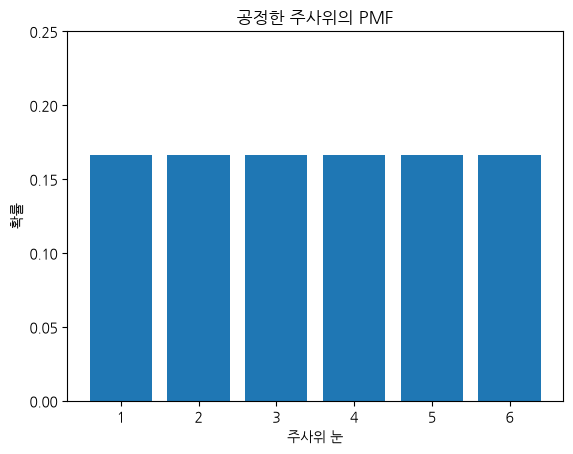

In [67]:
plt.bar(
    df["x"],
    df["pmf"]
)

plt.xlabel("주사위 눈")
plt.ylabel("확률")
plt.title("공정한 주사위의 PMF")
plt.ylim(0, 0.25)
plt.show()

In [71]:
df['cdf'] = df['pmf'].cumsum()

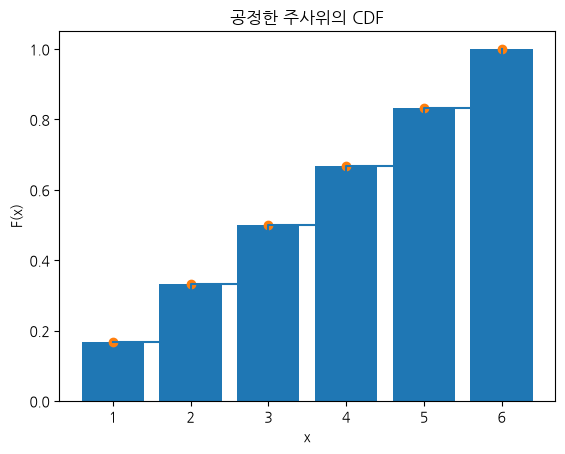

In [76]:
plt.bar(
    df["x"],
    df["cdf"]
)

plt.step(
    df["x"],
    df["cdf"],
    where="post"
)

plt.scatter(
    df["x"],
    df["cdf"]
)

plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("공정한 주사위의 CDF")
plt.ylim(0, 1.05)
plt.show()

In [78]:
df.drop(columns=['cmf'], inplace=True)

In [79]:
df

,x,pmf,cdf
0,1,0.166667,0.166667
1,2,0.166667,0.333333
2,3,0.166667,0.500000
3,4,0.166667,0.666667
4,5,0.166667,0.833333
5,6,0.166667,1.000000


In [81]:
np.sum(df['x']*df['pmf'])

np.float64(3.5)

In [82]:
rng = np.random.default_rng()

In [107]:
dice = rng.integers(1,7,10000)
# print(dice)
print(dice.mean())

3.5157


In [109]:
rolls = rng.integers(
    low=1,
    high=7,
    size=10000
)

cumulative_mean = (np.cumsum(rolls) / np.arange(1, len(rolls) + 1))
cumulative_mean

array([3.        , 3.5       , 2.66666667, ..., 3.51980396, 3.51985199,
       3.5197    ], shape=(10000,))

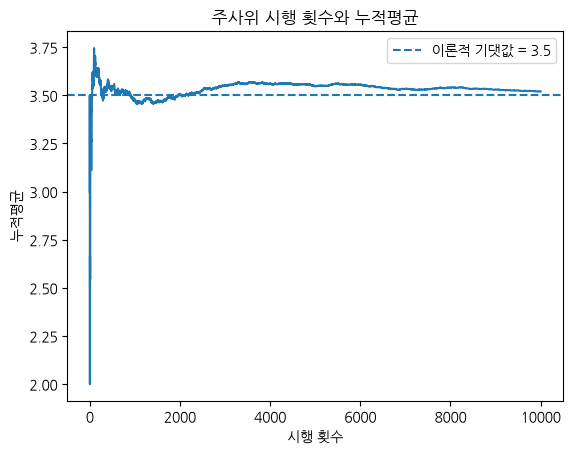

In [112]:
plt.plot(cumulative_mean)
plt.axhline(
    3.5,
    linestyle="--",
    label="이론적 기댓값 = 3.5"
)

plt.xlabel("시행 횟수")
plt.ylabel("누적평균")
plt.title("주사위 시행 횟수와 누적평균")
plt.legend()
plt.show()

In [113]:
mu = 3.5

variance = np.sum(((df["x"] - mu) ** 2)* df["pmf"])

print(variance)

2.9166666666666665


In [121]:
(((df["x"] - mu)**2)*df['pmf']).sum()

np.float64(2.9166666666666665)

In [123]:
rolls.var(ddof=1)

np.float64(2.8913010401040102)

In [126]:
rolls = rng.integers(
    1,
    7,
    size=100000
)

print(
    "표본평균:",
    rolls.mean()
)

print(
    "표본분산:",
    rolls.var(ddof=1)
)

print(
    "이론평균:",
    3.5
)

print(
    "이론분산:",
    35 / 12
)

표본평균: 3.49707
표본분산: 2.912060535705357
이론평균: 3.5
이론분산: 2.9166666666666665


In [127]:
dice = stats.randint(
    low=1,
    high=7
)

In [132]:
dice.pmf(1)

np.float64(0.16666666666666666)

In [133]:
x = np.arange(1, 7)

dice.pmf(x)

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [134]:
sample = dice.rvs(
    size=20,
    random_state=42
)

print(sample)

[4 5 3 5 5 2 3 3 3 5 4 3 6 5 2 4 6 6 2 4]


In [135]:
sample = dice.rvs(
    size=10000,
    random_state=42
)

In [136]:
frequency = (
    pd.Series(sample)
    .value_counts()
    .sort_index()
)

frequency

1    1665
2    1692
3    1625
4    1672
5    1689
6    1657
Name: count, dtype: int64

In [139]:
relative_frequency = (
    frequency / len(sample)
)

relative_frequency

1    0.1665
2    0.1692
3    0.1625
4    0.1672
5    0.1689
6    0.1657
Name: count, dtype: float64

In [140]:
comparison_df = pd.DataFrame({
    "이론확률": dice.pmf(
        np.arange(1, 7)
    ),
    "상대도수": relative_frequency
})

comparison_df

,이론확률,상대도수
1,0.166667,0.1665
2,0.166667,0.1692
3,0.166667,0.1625
4,0.166667,0.1672
5,0.166667,0.1689
6,0.166667,0.1657


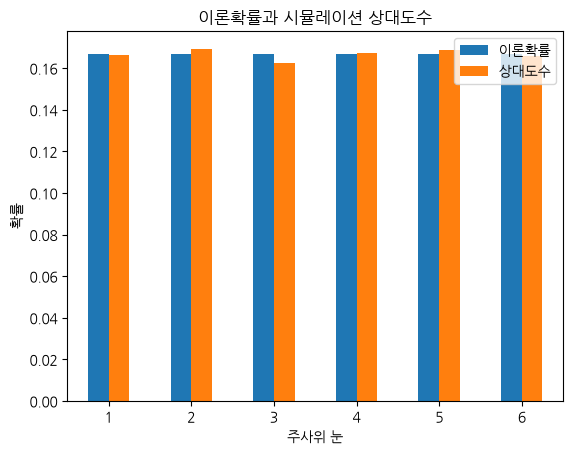

In [141]:
comparison_df.plot(
    kind="bar"
)

plt.xlabel("주사위 눈")
plt.ylabel("확률")
plt.title("이론확률과 시뮬레이션 상대도수")
plt.xticks(rotation=0)
plt.show()

In [142]:
custom_distribution = pd.DataFrame({
    "x": [0, 1, 2, 3],
    "pmf": [0.1, 0.3, 0.4, 0.2]
})
custom_distribution

,x,pmf
0,0,0.1
1,1,0.3
2,2,0.4
3,3,0.2


In [147]:
np.sum(custom_distribution['x'] * custom_distribution['pmf'])

np.float64(1.7000000000000002)

In [148]:
custom_mean = np.sum(
    custom_distribution["x"]
    * custom_distribution["pmf"]
)

print(custom_mean)

1.7000000000000002


In [149]:
custom_variance = np.sum(
    (
        custom_distribution["x"]
        - custom_mean
    ) ** 2
    * custom_distribution["pmf"]
)

print(custom_variance)

0.81


In [150]:
custom_distribution["cdf"] = (
    custom_distribution["pmf"].cumsum()
)

custom_distribution

,x,pmf,cdf
0,0,0.1,0.1
1,1,0.3,0.4
2,2,0.4,0.8
3,3,0.2,1.0


In [151]:
def discrete_distribution_summary(
    values,
    probabilities
):
    """
    이산확률분포의 PMF, CDF, 평균, 분산,
    표준편차를 계산합니다.
    """
    values = np.asarray(
        values,
        dtype=float
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )

    if len(values) != len(probabilities):
        raise ValueError(
            "값과 확률의 개수가 같아야 합니다."
        )

    if np.any(probabilities < 0):
        raise ValueError(
            "확률은 음수가 될 수 없습니다."
        )

    if not np.isclose(
        probabilities.sum(),
        1.0
    ):
        raise ValueError(
            "확률의 합은 1이어야 합니다."
        )

    expected_value = np.sum(
        values * probabilities
    )

    variance = np.sum(
        (
            values - expected_value
        ) ** 2
        * probabilities
    )

    standard_deviation = np.sqrt(
        variance
    )

    result_df = pd.DataFrame({
        "x": values,
        "pmf": probabilities,
        "cdf": np.cumsum(
            probabilities
        )
    })

    return {
        "table": result_df,
        "mean": expected_value,
        "variance": variance,
        "std": standard_deviation
    }

In [152]:
result = discrete_distribution_summary(
    values=[1, 2, 3, 4, 5, 6],
    probabilities=[1/6] * 6
)

print(result["table"])
print("기댓값:", result["mean"])
print("분산:", result["variance"])
print("표준편차:", result["std"])

     x       pmf       cdf
0  1.0  0.166667  0.166667
1  2.0  0.166667  0.333333
2  3.0  0.166667  0.500000
3  4.0  0.166667  0.666667
4  5.0  0.166667  0.833333
5  6.0  0.166667  1.000000
기댓값: 3.5
분산: 2.9166666666666665
표준편차: 1.707825127659933


In [155]:
result['table']

,x,pmf,cdf
0,1.0,0.166667,0.166667
1,2.0,0.166667,0.333333
2,3.0,0.166667,0.500000
3,4.0,0.166667,0.666667
4,5.0,0.166667,0.833333
5,6.0,0.166667,1.000000


확률합: 0.9999999999999999
   x       pmf       cdf
0  1  0.166667  0.166667
1  2  0.166667  0.333333
2  3  0.166667  0.500000
3  4  0.166667  0.666667
4  5  0.166667  0.833333
5  6  0.166667  1.000000
기댓값: 3.5
분산: 2.9166666666666665
표준편차: 1.707825127659933


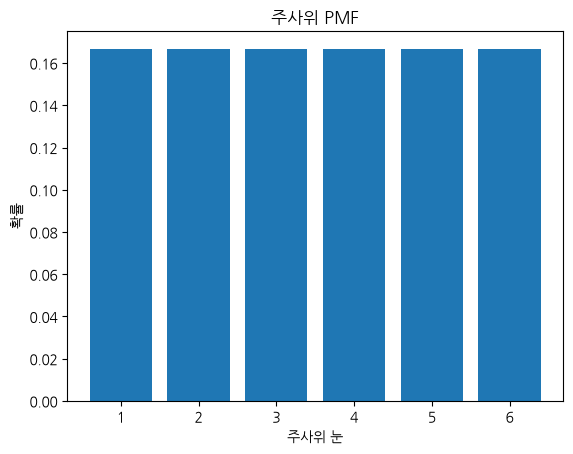

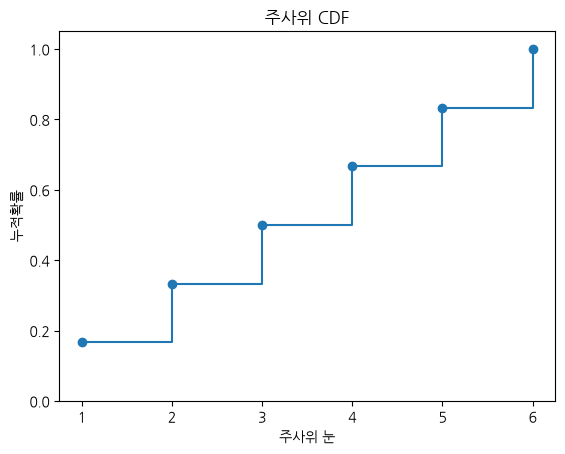

P(X=4): 0.16666666666666666
P(X<=4): 0.6666666666666666
P(X>4): 0.33333333333333337
SciPy 평균: 3.5
SciPy 분산: 2.9166666666666665
표본평균: 3.4999
표본분산: 2.91969195919592
       이론확률    상대도수
1  0.166667  0.1665
2  0.166667  0.1692
3  0.166667  0.1625
4  0.166667  0.1672
5  0.166667  0.1689
6  0.166667  0.1657


In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


# 1. 주사위 확률분포 만들기
x = np.arange(1, 7)

pmf = np.repeat(
    1 / 6,
    6
)

dice_df = pd.DataFrame({
    "x": x,
    "pmf": pmf
})


# 2. PMF 조건 확인
print(
    "확률합:",
    dice_df["pmf"].sum()
)


# 3. CDF 계산
dice_df["cdf"] = (
    dice_df["pmf"].cumsum()
)

print(dice_df)


# 4. 기댓값
mean = np.sum(
    dice_df["x"]
    * dice_df["pmf"]
)

print("기댓값:", mean)


# 5. 분산
variance = np.sum(
    (
        dice_df["x"] - mean
    ) ** 2
    * dice_df["pmf"]
)

print("분산:", variance)


# 6. 표준편차
std = np.sqrt(
    variance
)

print("표준편차:", std)


# 7. PMF 그래프
plt.bar(
    dice_df["x"],
    dice_df["pmf"]
)

plt.xlabel("주사위 눈")
plt.ylabel("확률")
plt.title("주사위 PMF")
plt.show()


# 8. CDF 그래프
plt.step(
    dice_df["x"],
    dice_df["cdf"],
    where="post"
)

plt.scatter(
    dice_df["x"],
    dice_df["cdf"]
)

plt.xlabel("주사위 눈")
plt.ylabel("누적확률")
plt.title("주사위 CDF")
plt.ylim(0, 1.05)
plt.show()


# 9. SciPy 분포 객체
dice = stats.randint(
    low=1,
    high=7
)

print(
    "P(X=4):",
    dice.pmf(4)
)

print(
    "P(X<=4):",
    dice.cdf(4)
)

print(
    "P(X>4):",
    dice.sf(4)
)

print(
    "SciPy 평균:",
    dice.mean()
)

print(
    "SciPy 분산:",
    dice.var()
)


# 10. 시뮬레이션
sample = dice.rvs(
    size=10000,
    random_state=42
)

print(
    "표본평균:",
    sample.mean()
)

print(
    "표본분산:",
    sample.var(ddof=1)
)


# 11. 상대도수
relative_frequency = (
    pd.Series(sample)
    .value_counts(normalize=True)
    .sort_index()
)

comparison = pd.DataFrame({
    "이론확률": dice.pmf(x),
    "상대도수": relative_frequency
})

print(comparison)

In [157]:
x = np.array([0,1,2,3])
pmf = np.array([0.1, 0.2, 0.4, 0.3])
df = pd.DataFrame({'x':x, 'pmf':pmf})
df

,x,pmf
0,0,0.1
1,1,0.2
2,2,0.4
3,3,0.3


In [173]:
df.loc[df['x'] == 2, 'pmf']

2    0.4
Name: pmf, dtype: float64

In [158]:
df['pmf'].sum()

np.float64(1.0)

In [161]:
# P(X=2)
pmf[2]

np.float64(0.4)

In [162]:
x==2

array([False, False,  True, False])

In [ ]:
pmf[x==2]

np.float64(0.4)

In [178]:
# P(X<=2)
df['cdf'] = df['pmf'].cumsum()
df.loc[df['x'] == 2, 'cdf']

2    0.7
Name: cdf, dtype: float64

In [181]:
# P(X>1)
1-df.loc[df['x'] == 1, 'cdf']

1    0.7
Name: cdf, dtype: float64

In [182]:
df

,x,pmf,cdf
0,0,0.1,0.1
1,1,0.2,0.3
2,2,0.4,0.7
3,3,0.3,1.0


In [184]:
np.sum(df['x']*df['pmf'])

np.float64(1.9)

In [190]:
np.sum(((df['x']-1.9)**2)*df['pmf'])

np.float64(0.8899999999999999)

In [165]:
x = np.array([
    0, 1, 2, 3
])

pmf = np.array([
    0.1, 0.2, 0.4, 0.3
])

print("확률합:", pmf.sum())

print(
    "P(X=2):",
    pmf[x == 2].sum()
)

print(
    "P(X<=2):",
    pmf[x <= 2].sum()
)

print(
    "P(X>1):",
    pmf[x > 1].sum()
)

mean = np.sum(
    x * pmf
)

variance = np.sum(
    (x - mean) ** 2
    * pmf
)

std = np.sqrt(
    variance
)

print("기댓값:", mean)
print("분산:", variance)
print("표준편차:", std)

확률합: 1.0
P(X=2): 0.4
P(X<=2): 0.7000000000000001
P(X>1): 0.7
기댓값: 1.9
분산: 0.8899999999999999
표준편차: 0.9433981132056604


In [191]:
profit = np.array([
    10000,
    -1000
])

probabilities = np.array([
    1 / 6,
    5 / 6
])

expected_profit = np.sum(
    profit * probabilities
)

print(
    "게임 1회의 기대이익:",
    expected_profit,
    "원"
)

게임 1회의 기대이익: 833.3333333333331 원


In [193]:
dice = stats.randint(1,7)
dice

In [195]:
dice.pmf(4)

np.float64(0.16666666666666666)

In [196]:
x = np.arange(1,7)
x

array([1, 2, 3, 4, 5, 6])

In [199]:
dice.pmf(x)

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [200]:
dice.var()

np.float64(2.9166666666666665)

In [203]:
x.var()

np.float64(2.9166666666666665)

In [204]:
outcomes = []

for die1 in range(1, 7):
    for die2 in range(1, 7):
        outcomes.append({
            "die1": die1,
            "die2": die2,
            "sum": die1 + die2
        })

two_dice_df = pd.DataFrame(outcomes)

two_dice_df.head()

,die1,die2,sum
0,1,1,2
1,1,2,3
2,1,3,4
3,1,4,5
4,1,5,6


In [206]:
sum_distribution = (
    two_dice_df["sum"]
    .value_counts(normalize=True)
    .sort_index()
)

sum_distribution

sum
2     0.027778
3     0.055556
4     0.083333
5     0.111111
6     0.138889
7     0.166667
8     0.138889
9     0.111111
10    0.083333
11    0.055556
12    0.027778
Name: proportion, dtype: float64

In [208]:
sum_distribution.sum()

np.float64(1.0)

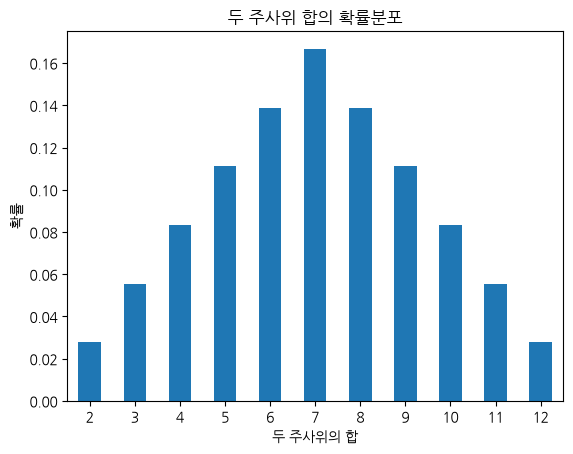

In [209]:
sum_distribution.plot(
    kind="bar"
)

plt.xlabel("두 주사위의 합")
plt.ylabel("확률")
plt.title("두 주사위 합의 확률분포")
plt.xticks(rotation=0)
plt.show()

In [210]:
rewards = np.array([
    0,
    0,
    1000,
    2000,
    3000,
    6000
])

probabilities = np.repeat(
    1 / 6,
    6
)

expected_reward = np.sum(
    rewards * probabilities
)

print(
    "기대지급금:",
    expected_reward,
    "원"
)

기대지급금: 2000.0 원


   x       pmf       cdf
0  1  0.166667  0.166667
1  2  0.166667  0.333333
2  3  0.166667  0.500000
3  4  0.166667  0.666667
4  5  0.166667  0.833333
5  6  0.166667  1.000000
P(X=4): 0.16666666666666666
P(X<=4): 0.6666666666666666
P(X>4): 0.33333333333333337
P(X>=3): 0.6666666666666667
P(2<=X<=5): 0.6666666666666667
기댓값: 3.5
분산: 2.9166666666666665
표준편차: 1.707825127659933
공식 기댓값: 3.5
공식 분산: 2.9166666666666665


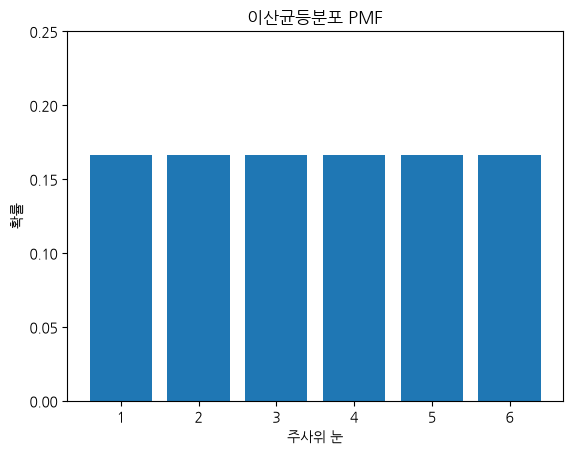

표본평균: 3.50312
표본분산: 2.9156994225942263
       이론확률     상대도수
1  0.166667  0.16592
2  0.166667  0.16799
3  0.166667  0.16390
4  0.166667  0.16776
5  0.166667  0.16810
6  0.166667  0.16633
두 주사위 합의 분포:
2     0.027778
3     0.055556
4     0.083333
5     0.111111
6     0.138889
7     0.166667
8     0.138889
9     0.111111
10    0.083333
11    0.055556
12    0.027778
Name: proportion, dtype: float64


In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


# 1. 1부터 6까지의 이산균등분포
dice = stats.randint(
    low=1,
    high=7
)

x = np.arange(1, 7)


# 2. PMF
pmf = dice.pmf(x)

distribution_df = pd.DataFrame({
    "x": x,
    "pmf": pmf,
    "cdf": dice.cdf(x)
})

print(distribution_df)


# 3. 확률 계산
print(
    "P(X=4):",
    dice.pmf(4)
)

print(
    "P(X<=4):",
    dice.cdf(4)
)

print(
    "P(X>4):",
    dice.sf(4)
)

print(
    "P(X>=3):",
    dice.sf(2)
)

print(
    "P(2<=X<=5):",
    dice.cdf(5) - dice.cdf(1)
)


# 4. 평균과 분산
print(
    "기댓값:",
    dice.mean()
)

print(
    "분산:",
    dice.var()
)

print(
    "표준편차:",
    dice.std()
)


# 5. 공식 확인
a = 1
b = 6
n = b - a + 1

mean_formula = (
    a + b
) / 2

variance_formula = (
    n ** 2 - 1
) / 12

print(
    "공식 기댓값:",
    mean_formula
)

print(
    "공식 분산:",
    variance_formula
)


# 6. PMF 그래프
plt.bar(
    x,
    pmf
)

plt.xlabel("주사위 눈")
plt.ylabel("확률")
plt.title("이산균등분포 PMF")
plt.ylim(0, 0.25)
plt.show()


# 7. 난수 시뮬레이션
sample = dice.rvs(
    size=100000,
    random_state=42
)

print(
    "표본평균:",
    sample.mean()
)

print(
    "표본분산:",
    sample.var(ddof=1)
)


# 8. 상대도수
relative_frequency = (
    pd.Series(sample)
    .value_counts(normalize=True)
    .sort_index()
)

comparison = pd.DataFrame({
    "이론확률": pmf,
    "상대도수": relative_frequency
})

print(comparison)


# 9. 두 주사위 합
outcomes = []

for die1 in range(1, 7):
    for die2 in range(1, 7):
        outcomes.append(
            die1 + die2
        )

sum_distribution = (
    pd.Series(outcomes)
    .value_counts(normalize=True)
    .sort_index()
)

print(
    "두 주사위 합의 분포:"
)

print(sum_distribution)

In [212]:
x = stats.randint(1,21)
x

In [214]:
x.pmf(10)

np.float64(0.05)

In [220]:
np.sum(x.pmf(np.arange(0,22,2)))

np.float64(0.5)

In [221]:
x = np.arange(1, 21)
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [224]:
x%2==0

array([False,  True, False,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False,  True])

In [225]:
p = np.repeat(1/20, 20)
p

array([0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05])

In [230]:
np.sum(p[x%2==0])

np.float64(0.5)

In [228]:
x[x%2==0]

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20])

In [231]:
distribution = stats.randint(
    low=3,
    high=11
)

sample = distribution.rvs(
    size=100000,
    random_state=42
)

In [232]:
print(
    "이론평균:",
    distribution.mean()
)

print(
    "표본평균:",
    sample.mean()
)

print(
    "이론분산:",
    distribution.var()
)

print(
    "표본분산:",
    sample.var(ddof=1)
)

이론평균: 6.5
표본평균: 6.50551
이론분산: 5.25
표본분산: 5.235121991119911


In [236]:
distribution.var()

np.float64(5.25)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
p = 0.3
x = np.array([0,1])

In [3]:
pmf = np.array([1-p, p])
pmf

array([0.7, 0.3])

In [4]:
df = pd.DataFrame({'x':x, 'pmf':pmf})
df

,x,pmf
0,0,0.7
1,1,0.3


<BarContainer object of 2 artists>

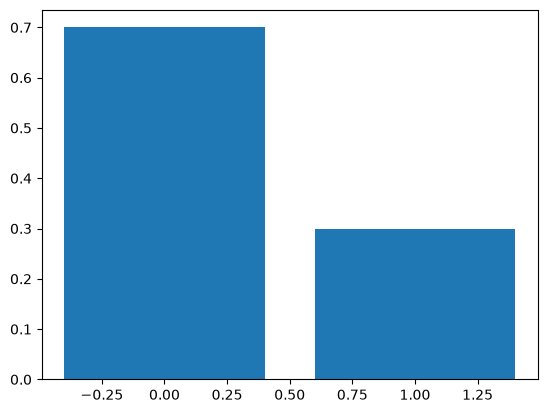

In [5]:
plt.bar(df['x'], df['pmf'])

<Axes: xlabel='x', ylabel='pmf'>

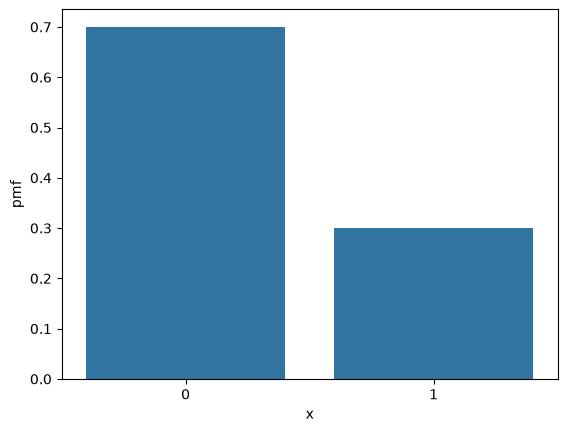

In [7]:
sns.barplot(df, x='x', y='pmf')

<Axes: >

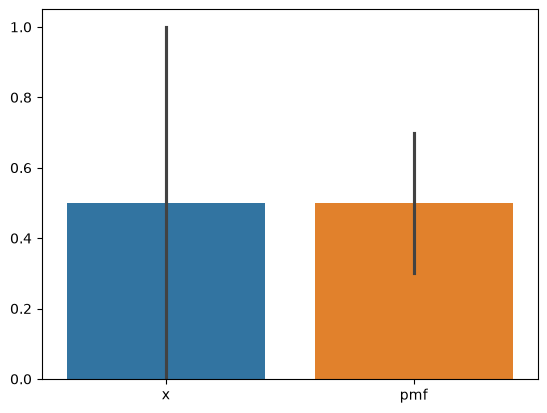

In [8]:
sns.barplot(df)

In [9]:
distribution = stats.bernoulli(p=0.3)
print(
    "P(X=0):",
    distribution.pmf(0)
)

print(
    "P(X=1):",
    distribution.pmf(1)
)

P(X=0): 0.7000000000000002
P(X=1): 0.3


In [10]:
distribution.pmf([0, 1])

array([0.7, 0.3])

In [11]:
0.3*(1-0.3)

0.21

In [12]:
p = np.linspace(0,1,101)
v = p*(1-p)

In [15]:
p

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

In [19]:
v

array([0.    , 0.0099, 0.0196, 0.0291, 0.0384, 0.0475, 0.0564, 0.0651,
       0.0736, 0.0819, 0.09  , 0.0979, 0.1056, 0.1131, 0.1204, 0.1275,
       0.1344, 0.1411, 0.1476, 0.1539, 0.16  , 0.1659, 0.1716, 0.1771,
       0.1824, 0.1875, 0.1924, 0.1971, 0.2016, 0.2059, 0.21  , 0.2139,
       0.2176, 0.2211, 0.2244, 0.2275, 0.2304, 0.2331, 0.2356, 0.2379,
       0.24  , 0.2419, 0.2436, 0.2451, 0.2464, 0.2475, 0.2484, 0.2491,
       0.2496, 0.2499, 0.25  , 0.2499, 0.2496, 0.2491, 0.2484, 0.2475,
       0.2464, 0.2451, 0.2436, 0.2419, 0.24  , 0.2379, 0.2356, 0.2331,
       0.2304, 0.2275, 0.2244, 0.2211, 0.2176, 0.2139, 0.21  , 0.2059,
       0.2016, 0.1971, 0.1924, 0.1875, 0.1824, 0.1771, 0.1716, 0.1659,
       0.16  , 0.1539, 0.1476, 0.1411, 0.1344, 0.1275, 0.1204, 0.1131,
       0.1056, 0.0979, 0.09  , 0.0819, 0.0736, 0.0651, 0.0564, 0.0475,
       0.0384, 0.0291, 0.0196, 0.0099, 0.    ])

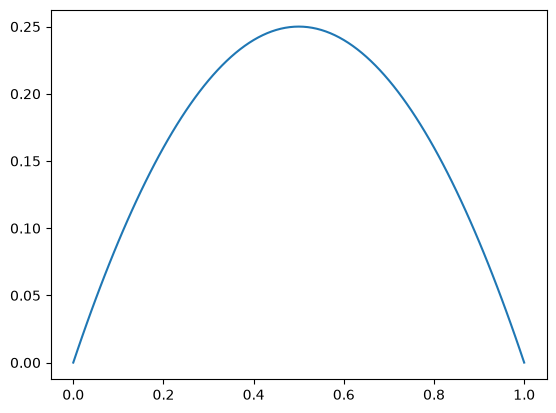

In [17]:
plt.plot(p, v)

In [20]:
distribution = stats.bernoulli(
    p=0.3
)

In [21]:
distribution.var()

np.float64(0.21)

In [22]:
distribution.std()

np.float64(0.458257569495584)

In [31]:
samples = distribution.rvs(size=20, random_state=42)
samples

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0])

In [32]:
samples.sum()

np.int64(6)

In [33]:
samples.mean()

np.float64(0.3)

In [34]:
6/20

0.3

In [36]:
sample_sizes = [
    10,
    100,
    1000,
    100000
]

for n in sample_sizes:
    sample = distribution.rvs(
        size=n,
        random_state=n
    )

    print(
        f"n={n}, 표본평균={sample.mean():.4f}"
    )

n=10, 표본평균=0.3000
n=100, 표본평균=0.2500
n=1000, 표본평균=0.2920
n=100000, 표본평균=0.3005


In [42]:
p = 0.3
plt.rcParams['font.family'] = 'NanumGothic'

In [43]:
sample = distribution.rvs(
    size=10000,
    random_state=42
)

cumulative_rate = (
    np.cumsum(sample)
    / np.arange(1, len(sample) + 1)
)

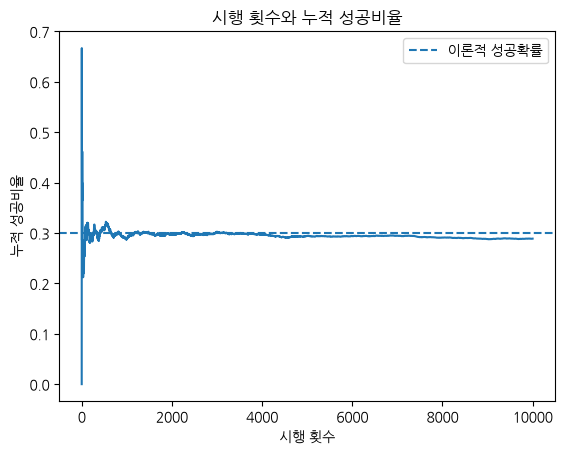

In [44]:
plt.plot(
    cumulative_rate
)

plt.axhline(
    p,
    linestyle="--",
    label="이론적 성공확률"
)

plt.xlabel("시행 횟수")
plt.ylabel("누적 성공비율")
plt.title("시행 횟수와 누적 성공비율")
plt.legend()
plt.show()

In [45]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [47]:
tips['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [49]:
tips['smoker_binary'] = tips['smoker'].map({'Yes':1, 'No':0})

In [50]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size,smoker_binary
0,16.99,1.01,Female,No,Sun,Dinner,2,0
1,10.34,1.66,Male,No,Sun,Dinner,3,0
2,21.01,3.50,Male,No,Sun,Dinner,3,0
3,23.68,3.31,Male,No,Sun,Dinner,2,0
4,24.59,3.61,Female,No,Sun,Dinner,4,0


In [51]:
tips['smoker_binary'].value_counts()

smoker_binary
0    151
1     93
Name: count, dtype: int64

In [52]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size,smoker_binary
0,16.99,1.01,Female,No,Sun,Dinner,2,0
1,10.34,1.66,Male,No,Sun,Dinner,3,0
2,21.01,3.50,Male,No,Sun,Dinner,3,0
3,23.68,3.31,Male,No,Sun,Dinner,2,0
4,24.59,3.61,Female,No,Sun,Dinner,4,0


In [59]:
tips['smoker_binary'] = tips['smoker_binary'].astype(int)
tips['smoker_binary']

0      0
1      0
2      0
3      0
4      0
      ..
239    0
240    1
241    1
242    0
243    0
Name: smoker_binary, Length: 244, dtype: int64

In [60]:
tips['smoker_binary'].mean()

np.float64(0.38114754098360654)

In [61]:
tips['smoker_binary'].sum()

np.int64(93)

In [62]:
defect = stats.bernoulli(
    p=0.02
)

print(
    "불량확률:",
    defect.pmf(1)
)

print(
    "정상확률:",
    defect.pmf(0)
)

print(
    "기댓값:",
    defect.mean()
)

print(
    "분산:",
    defect.var()
)

불량확률: 0.02
정상확률: 0.9800000000000002
기댓값: 0.02
분산: 0.0196


In [63]:
click = stats.bernoulli(
    p=0.08
)

click.pmf(1)

np.float64(0.08)

In [64]:
click.pmf(0)

np.float64(0.9199999999999998)

   x  pmf  cdf
0  0  0.7  0.7
1  1  0.3  1.0
확률합: 1.0
기댓값: 0.3
분산: 0.20999999999999996
공식 기댓값: 0.3
공식 분산: 0.21
P(X=0): 0.7000000000000002
P(X=1): 0.3
SciPy 평균: 0.3
SciPy 분산: 0.21


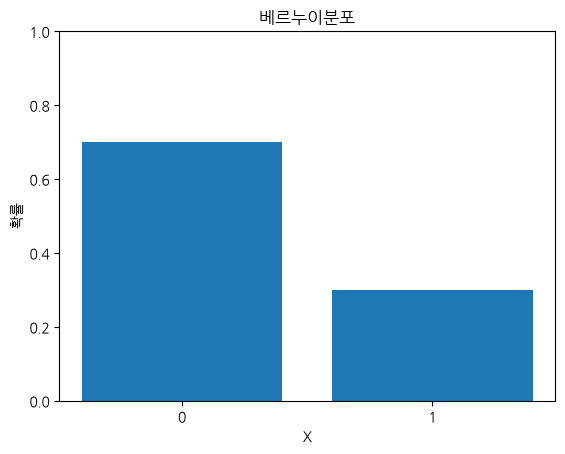

성공 횟수: 2887
표본 성공비율: 0.2887
표본분산: 0.20537284728472852


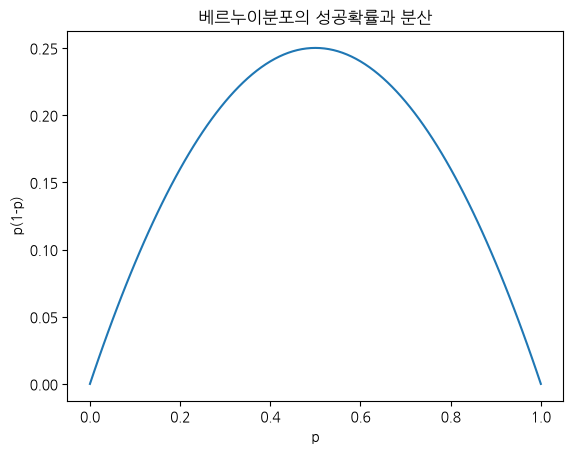

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


# 1. 성공확률
p = 0.3


# 2. 가능한 값과 확률
x = np.array([0, 1])

pmf = np.array([
    1 - p,
    p
])


# 3. 확률표
bernoulli_df = pd.DataFrame({
    "x": x,
    "pmf": pmf,
    "cdf": np.cumsum(pmf)
})

print(bernoulli_df)


# 4. PMF 조건 확인
print(
    "확률합:",
    bernoulli_df["pmf"].sum()
)


# 5. 기댓값
mean = np.sum(
    x * pmf
)

print("기댓값:", mean)


# 6. 분산
variance = np.sum(
    (x - mean) ** 2
    * pmf
)

print("분산:", variance)


# 7. 공식 확인
print(
    "공식 기댓값:",
    p
)

print(
    "공식 분산:",
    p * (1 - p)
)


# 8. SciPy 분포 객체
distribution = stats.bernoulli(
    p=p
)

print(
    "P(X=0):",
    distribution.pmf(0)
)

print(
    "P(X=1):",
    distribution.pmf(1)
)

print(
    "SciPy 평균:",
    distribution.mean()
)

print(
    "SciPy 분산:",
    distribution.var()
)


# 9. 그래프
plt.bar(
    x,
    pmf
)

plt.xticks([0, 1])
plt.xlabel("X")
plt.ylabel("확률")
plt.title("베르누이분포")
plt.ylim(0, 1)
plt.show()


# 10. 난수 생성
sample = distribution.rvs(
    size=10000,
    random_state=42
)

print(
    "성공 횟수:",
    sample.sum()
)

print(
    "표본 성공비율:",
    sample.mean()
)

print(
    "표본분산:",
    sample.var(ddof=1)
)


# 11. p와 분산 관계
p_values = np.linspace(
    0,
    1,
    101
)

variances = (
    p_values
    * (1 - p_values)
)

plt.plot(
    p_values,
    variances
)

plt.xlabel("p")
plt.ylabel("p(1-p)")
plt.title("베르누이분포의 성공확률과 분산")
plt.show()

In [66]:
defect = stats.bernoulli(
    p=0.05
)

print(
    "불량확률:",
    defect.pmf(1)
)

print(
    "정상확률:",
    defect.pmf(0)
)

print(
    "기댓값:",
    defect.mean()
)

print(
    "분산:",
    defect.var()
)

불량확률: 0.05
정상확률: 0.95
기댓값: 0.05
분산: 0.0475


In [68]:
import math

math.comb(10, 3)

120

In [69]:
math.perm(10,3)

720

In [70]:
n = 5
k = 2
p = 0.5

In [71]:
probability = (
    math.comb(n, k)
    * (p ** k)
    * ((1 - p) ** (n - k))
)

print(probability)

0.3125


In [72]:
x = np.arange(0, n + 1)
x

array([0, 1, 2, 3, 4, 5])

In [ ]:
pmf_manual = np.array([math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k)) for k in x])

pmf_manual

array([0.03125, 0.15625, 0.3125 , 0.3125 , 0.15625, 0.03125])

In [74]:
from scipy.stats import binom

pmf = binom.pmf(x, n, p)


In [75]:
pmf

array([0.03125, 0.15625, 0.3125 , 0.3125 , 0.15625, 0.03125])

In [76]:
binomial_df = pd.DataFrame({
    "successes": x,
    "pmf": pmf_manual
})

binomial_df

,successes,pmf
0,0,0.03125
1,1,0.15625
2,2,0.31250
3,3,0.31250
4,4,0.15625
5,5,0.03125


In [77]:
binomial_df.sum()

successes    15.0
pmf           1.0
dtype: float64

In [79]:
distribution = stats.binom(n=5, p=0.5)
distribution

In [80]:
distribution.pmf(2)

np.float64(0.31249999999999983)

In [81]:
x = np.arange(0,6)
x

array([0, 1, 2, 3, 4, 5])

In [82]:
pmf = distribution.pmf(x)
pmf

array([0.03125, 0.15625, 0.3125 , 0.3125 , 0.15625, 0.03125])

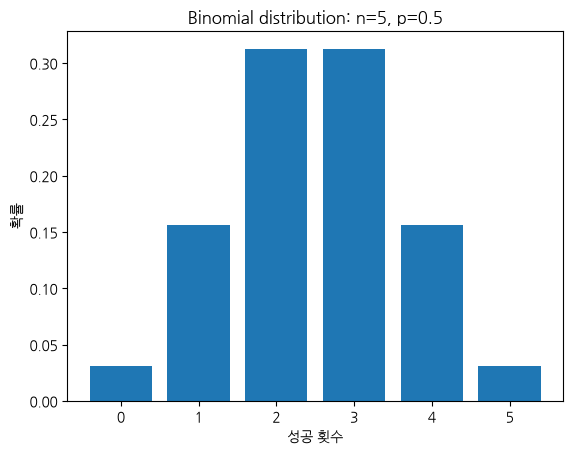

In [85]:
plt.bar(x, pmf)
plt.xlabel("성공 횟수")
plt.ylabel("확률")
plt.title("Binomial distribution: n=5, p=0.5")
plt.xticks(x)
plt.show()

In [86]:
purchase_count = stats.binom(
    n=10,
    p=0.3
)

In [88]:
purchase_count.pmf(3)

np.float64(0.2668279319999998)

In [91]:
purchase_count = stats.binom(
    n=10,
    p=0.3
)
purchase_count

In [92]:
purchase_count.pmf(3)

np.float64(0.2668279319999998)

In [101]:
purchase_count.cdf(3)

np.float64(0.6496107184000002)

In [102]:
print(
    "공식:",
    1 - (1 - 0.3) ** 10
)

print(
    "SciPy:",
    purchase_count.sf(0)
)

공식: 0.9717524751000001
SciPy: 0.9717524751


In [103]:
purchase_count.var()

np.float64(2.1)

In [104]:
n = 20
x = np.arange(0, n + 1)

p_values = [
    0.1,
    0.3,
    0.5,
    0.8
]

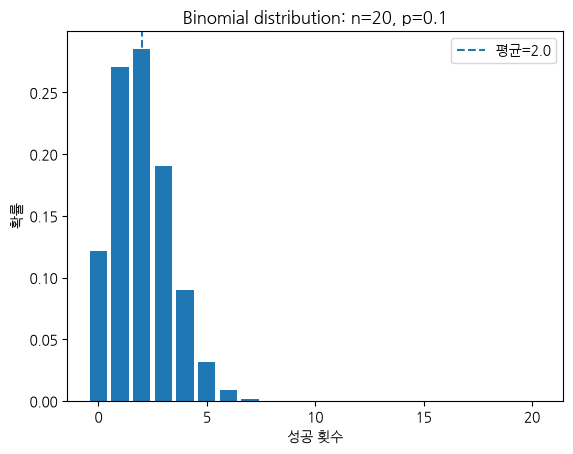

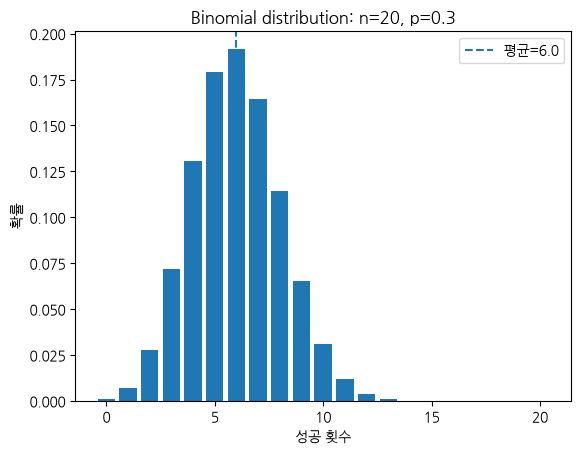

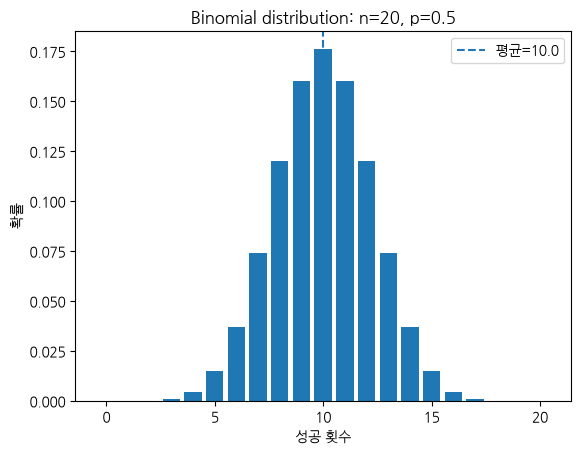

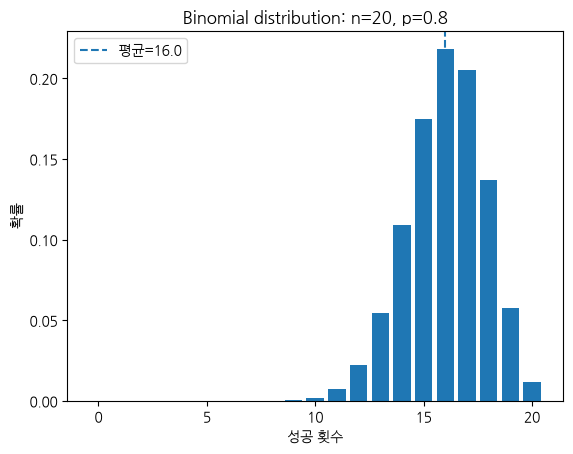

In [105]:
for p in p_values:
    pmf = stats.binom.pmf(
        x,
        n=n,
        p=p
    )

    plt.bar(
        x,
        pmf
    )

    plt.axvline(
        n * p,
        linestyle="--",
        label=f"평균={n*p:.1f}"
    )

    plt.xlabel("성공 횟수")
    plt.ylabel("확률")
    plt.title(f"Binomial distribution: n={n}, p={p}")
    plt.legend()
    plt.show()

In [106]:
prob_1 = stats.binom.pmf(
    2,
    n=10,
    p=0.2
)

prob_2 = stats.binom.pmf(
    8,
    n=10,
    p=0.8
)

print(prob_1)
print(prob_2)

0.30198988800000004
0.30198988799999993


In [108]:
defects = stats.binom(n=20, p=0.05)
defects

In [110]:
defects.pmf(1)

np.float64(0.37735360253530753)

In [112]:
defects.sf(1)

np.float64(0.2641604750561498)

In [113]:
quiz = stats.binom(n=10, p=0.25)
quiz

In [114]:
quiz.pmf(3)

np.float64(0.2502822875976561)

In [115]:
quiz.sf(4)

np.float64(0.07812690734863281)

In [118]:
1-quiz.cdf(4)

np.float64(0.07812690734863281)

In [119]:
quiz.mean()

np.float64(2.5)

     x       pmf       cdf
0    0  0.028248  0.028248
1    1  0.121061  0.149308
2    2  0.233474  0.382783
3    3  0.266828  0.649611
4    4  0.200121  0.849732
5    5  0.102919  0.952651
6    6  0.036757  0.989408
7    7  0.009002  0.998410
8    8  0.001447  0.999856
9    9  0.000138  0.999994
10  10  0.000006  1.000000
P(X=3): 0.2668279319999998
P(X<=3): 0.6496107184000002
P(X<3): 0.38278278639999974
P(X>3): 0.3503892815999998
P(X>=3): 0.6172172136000003
P(2<=X<=5): 0.8033426667000002
P(X>=1): 0.9717524751
평균: 3.0
분산: 2.1
표준편차: 1.449137674618944
공식 평균: 3.0
공식 분산: 2.0999999999999996
직접 계산 P(X=3): 0.2668279319999998


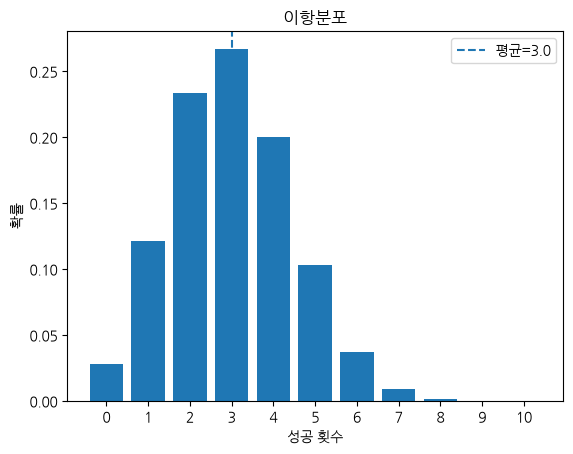

표본평균: 2.99737
표본분산: 2.086883951939519


In [120]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


# 1. 이항분포 설정
n = 10
p = 0.3

distribution = stats.binom(
    n=n,
    p=p
)


# 2. 가능한 성공 횟수
x = np.arange(
    0,
    n + 1
)


# 3. PMF와 CDF
distribution_df = pd.DataFrame({
    "x": x,
    "pmf": distribution.pmf(x),
    "cdf": distribution.cdf(x)
})

print(distribution_df)


# 4. 정확히 3번 성공
prob_exactly_3 = distribution.pmf(3)

print(
    "P(X=3):",
    prob_exactly_3
)


# 5. 3번 이하
print(
    "P(X<=3):",
    distribution.cdf(3)
)


# 6. 3번 미만
print(
    "P(X<3):",
    distribution.cdf(2)
)


# 7. 3번 초과
print(
    "P(X>3):",
    distribution.sf(3)
)


# 8. 3번 이상
print(
    "P(X>=3):",
    distribution.sf(2)
)


# 9. 2 이상 5 이하
print(
    "P(2<=X<=5):",
    distribution.cdf(5)
    - distribution.cdf(1)
)


# 10. 적어도 한 번 성공
print(
    "P(X>=1):",
    distribution.sf(0)
)


# 11. 평균과 분산
print(
    "평균:",
    distribution.mean()
)

print(
    "분산:",
    distribution.var()
)

print(
    "표준편차:",
    distribution.std()
)


# 12. 공식 확인
print(
    "공식 평균:",
    n * p
)

print(
    "공식 분산:",
    n * p * (1 - p)
)


# 13. 직접 PMF 계산
k = 3

manual_probability = (
    math.comb(n, k)
    * (p ** k)
    * ((1 - p) ** (n - k))
)

print(
    "직접 계산 P(X=3):",
    manual_probability
)


# 14. PMF 그래프
plt.bar(
    x,
    distribution.pmf(x)
)

plt.axvline(
    n * p,
    linestyle="--",
    label=f"평균={n*p}"
)

plt.xlabel("성공 횟수")
plt.ylabel("확률")
plt.title("이항분포")
plt.xticks(x)
plt.legend()
plt.show()


# 15. 시뮬레이션
samples = distribution.rvs(
    size=100000,
    random_state=42
)

print(
    "표본평균:",
    samples.mean()
)

print(
    "표본분산:",
    samples.var(ddof=1)
)

In [121]:
customers = stats.binom(n=15, p=0.2)

In [123]:
customers.pmf(3)

np.float64(0.25013889531904016)

In [124]:
customers.cdf(3)

np.float64(0.6481621045739516)

In [126]:
1-customers.cdf(2)

np.float64(0.6019767907450877)

In [127]:
1-customers.cdf(0)

np.float64(0.964815627911168)

In [128]:
customers.mean()

np.float64(3.0)

In [129]:
customers.var()

np.float64(2.4)

In [130]:
purchase = stats.binom(
    n=15,
    p=0.2
)

print(
    "P(X=3):",
    purchase.pmf(3)
)

print(
    "P(X<=3):",
    purchase.cdf(3)
)

print(
    "P(X>=3):",
    purchase.sf(2)
)

print(
    "P(X>=1):",
    purchase.sf(0)
)

print(
    "기댓값:",
    purchase.mean()
)

print(
    "분산:",
    purchase.var()
)

P(X=3): 0.25013889531904016
P(X<=3): 0.6481621045739516
P(X>=3): 0.6019767907450877
P(X>=1): 0.964815627911168
기댓값: 3.0
분산: 2.4


In [131]:
defects = stats.binom(n=50, p=0.02)
defects

In [132]:
defects.pmf(0)

np.float64(0.36416968008711703)

In [133]:
defects.pmf(1)

np.float64(0.37160171437460954)

In [134]:
1-defects.cdf(1)

np.float64(0.26422860553827376)

In [135]:
defects.mean()

np.float64(1.0)

In [136]:
defects.std()

np.float64(0.9899494936611666)

In [137]:
defect_count = stats.binom(
    n=50,
    p=0.02
)

print(
    "P(X=0):",
    defect_count.pmf(0)
)

print(
    "P(X=1):",
    defect_count.pmf(1)
)

print(
    "P(X>=2):",
    defect_count.sf(1)
)

print(
    "평균:",
    defect_count.mean()
)

print(
    "표준편차:",
    defect_count.std()
)

P(X=0): 0.36416968008711703
P(X=1): 0.37160171437460954
P(X>=2): 0.26422860553827376
평균: 1.0
표준편차: 0.9899494936611666


In [138]:
coins = stats.binom(n=8, p=0.5)
coins

In [150]:
x = np.arange(0,9)
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

<BarContainer object of 9 artists>

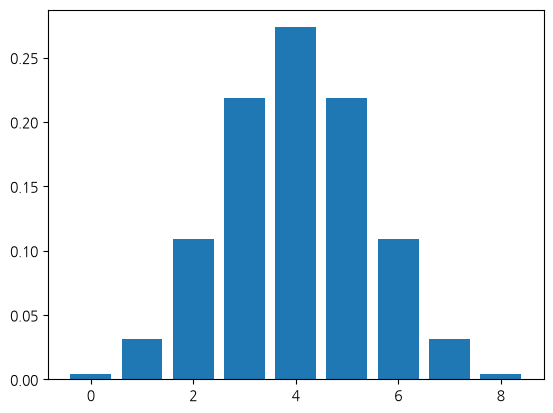

In [153]:
plt.bar(x, coins.pmf(x))

In [139]:
coins.pmf(4)

np.float64(0.27343749999999994)

In [141]:
coins.cdf(4)

np.float64(0.63671875)

In [142]:
1-coins.cdf(4)

np.float64(0.36328125)

In [143]:
coins.mean()

np.float64(4.0)

In [144]:
coins.var()

np.float64(2.0)

In [145]:
coin = stats.binom(
    n=8,
    p=0.5
)

print(
    "P(X=4):",
    coin.pmf(4)
)

print(
    "P(X<=4):",
    coin.cdf(4)
)

print(
    "P(X>=5):",
    coin.sf(4)
)

print(
    "평균:",
    coin.mean()
)

print(
    "분산:",
    coin.var()
)

P(X=4): 0.27343749999999994
P(X<=4): 0.63671875
P(X>=5): 0.36328125
평균: 4.0
분산: 2.0


In [146]:
n = 6
k = 2
p = 0.4

manual = (
    math.comb(n, k)
    * (p ** k)
    * ((1 - p) ** (n - k))
)

scipy_result = stats.binom.pmf(
    k,
    n=n,
    p=p
)

print(
    "직접 계산:",
    manual
)

print(
    "SciPy:",
    scipy_result
)

직접 계산: 0.31104000000000004
SciPy: 0.3110400000000002


In [148]:
stats.binom(n=n, p=p).pmf(k)

np.float64(0.3110400000000002)

In [149]:
math.comb(n, k)

15

In [154]:
lam = 4
k = 2

In [155]:
math.factorial(5)

120

In [156]:
5*4*3*2*1

120

In [160]:
call_count = stats.poisson(mu=4)

In [161]:
call_count.pmf(2)

np.float64(0.14652511110987343)

In [162]:
x = np.arange(0, 16)

pmf = call_count.pmf(x)
poisson_df = pd.DataFrame({
    "calls": x,
    "pmf": pmf,
    "cdf": call_count.cdf(x)
})

poisson_df

,calls,pmf,cdf
0,0,0.018316,0.018316
1,1,0.073263,0.091578
2,2,0.146525,0.238103
3,3,0.195367,0.433470
4,4,0.195367,0.628837
5,5,0.156293,0.785130
6,6,0.104196,0.889326
7,7,0.059540,0.948866
8,8,0.029770,0.978637
9,9,0.013231,0.991868


In [163]:
poisson_df.sum()

calls    120.000000
pmf        0.999995
cdf       12.000001
dtype: float64

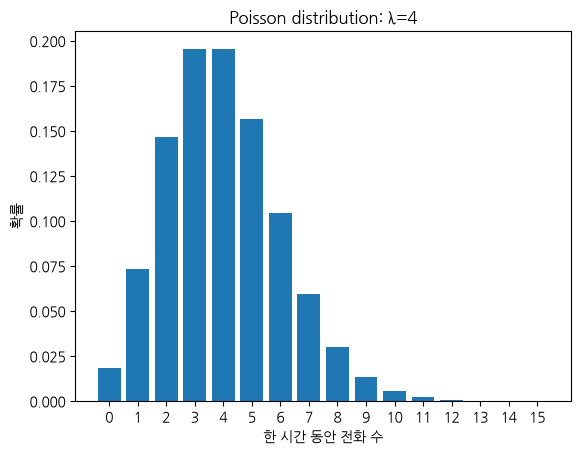

In [164]:
plt.bar(
    x,
    pmf
)

plt.xlabel("한 시간 동안 전화 수")
plt.ylabel("확률")
plt.title("Poisson distribution: λ=4")
plt.xticks(x)
plt.show()

In [167]:
1-call_count.pmf(0)

np.float64(0.9816843611112658)

In [166]:
math.exp(-4)

0.01831563888873418

In [168]:
call_count.mean()

np.float64(4.0)

In [170]:
call_count.var()

np.float64(4.0)

In [171]:
call_count.std()

np.float64(2.0)

In [172]:
x = np.arange(0, 50)

pmf = call_count.pmf(x)

mean_manual = np.sum(
    x * pmf
)

print(mean_manual)

3.9999999999999987


In [177]:
lambda_values = [
    0.5,
    2,
    5,
    10,
    20
]

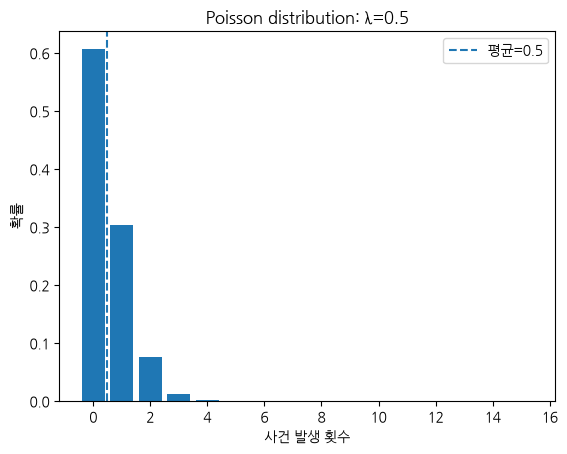

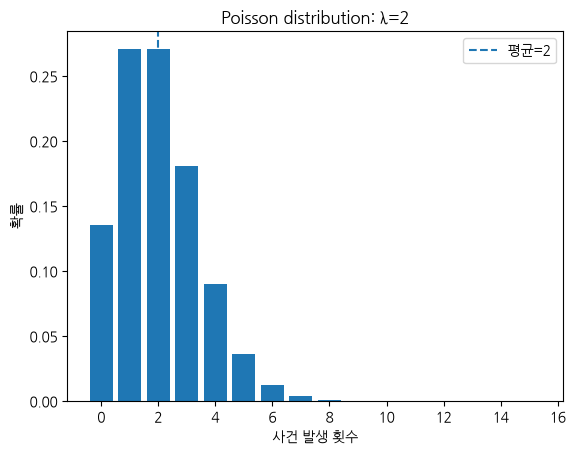

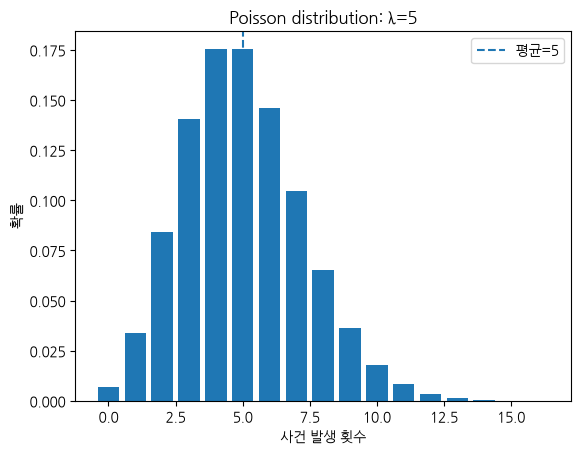

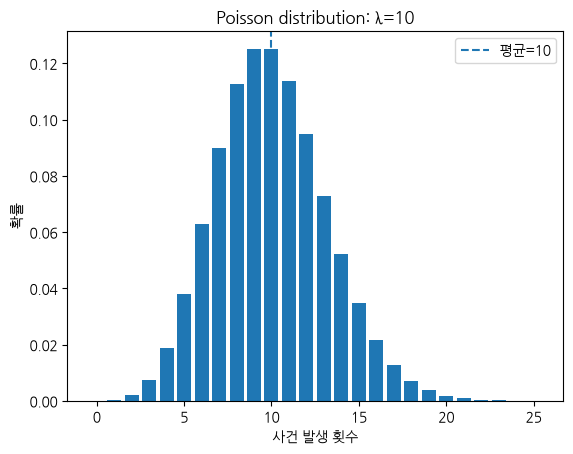

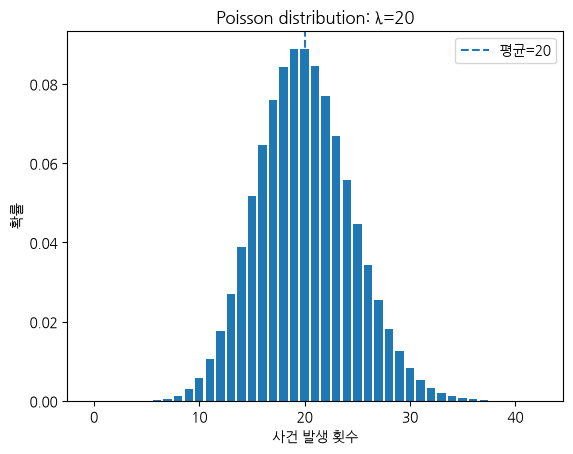

In [178]:
for lam in lambda_values:
    max_x = max(
        15,
        int(lam + 5 * np.sqrt(lam))
    )

    x = np.arange(
        0,
        max_x + 1
    )

    pmf = stats.poisson.pmf(
        x,
        mu=lam
    )

    plt.bar(
        x,
        pmf
    )

    plt.axvline(
        lam,
        linestyle="--",
        label=f"평균={lam}"
    )

    plt.xlabel("사건 발생 횟수")
    plt.ylabel("확률")
    plt.title(f"Poisson distribution: λ={lam}")
    plt.legend()
    plt.show()

In [179]:
distribution = stats.poisson(
    mu=4
)

sample = distribution.rvs(
    size=20,
    random_state=42
)

print(sample)

[5 4 4 4 2 5 2 5 3 5 7 1 4 3 3 0 5 4 6 7]


In [180]:
samples = distribution.rvs(
    size=100000,
    random_state=42
)

print(
    "표본평균:",
    samples.mean()
)

print(
    "이론평균:",
    distribution.mean()
)

print(
    "표본분산:",
    samples.var(ddof=1)
)

print(
    "이론분산:",
    distribution.var()
)

표본평균: 4.00429
이론평균: 4.0
표본분산: 4.006611662016621
이론분산: 4.0


In [181]:
x = np.arange(0, 16)

relative_frequency = (
    pd.Series(samples)
    .value_counts(normalize=True)
    .sort_index()
    .reindex(
        x,
        fill_value=0
    )
)

comparison = pd.DataFrame({
    "이론확률": distribution.pmf(x),
    "상대도수": relative_frequency
})

comparison

,이론확률,상대도수
0,0.018316,0.01783
1,0.073263,0.07294
2,0.146525,0.14625
3,0.195367,0.19650
4,0.195367,0.19493
5,0.156293,0.15708
6,0.104196,0.10313
7,0.059540,0.06023
8,0.029770,0.02918
9,0.013231,0.01347


In [182]:
hourly_customers = np.array([
    3, 5, 4, 2, 6,
    4, 3, 5, 7, 4,
    2, 3, 5, 4, 6,
    3, 4, 5, 2, 4
])

In [183]:
sample_mean = hourly_customers.mean()
sample_variance = hourly_customers.var(ddof=1)

print("표본평균:", sample_mean)
print("표본분산:", sample_variance)

표본평균: 4.05
표본분산: 1.9447368421052633


     x       pmf       cdf
0    0  0.018316  0.018316
1    1  0.073263  0.091578
2    2  0.146525  0.238103
3    3  0.195367  0.433470
4    4  0.195367  0.628837
5    5  0.156293  0.785130
6    6  0.104196  0.889326
7    7  0.059540  0.948866
8    8  0.029770  0.978637
9    9  0.013231  0.991868
10  10  0.005292  0.997160
11  11  0.001925  0.999085
12  12  0.000642  0.999726
13  13  0.000197  0.999924
14  14  0.000056  0.999980
15  15  0.000015  0.999995
P(X=2): 0.14652511110987343
직접 계산 P(X=2): 0.14652511110987343
P(X<=4): 0.6288369351798734
P(X<4): 0.43347012036670896
P(X>4): 0.3711630648201266
P(X>=4): 0.566529879633291
P(2<=X<=5): 0.6935521925867343
P(X=0): 0.01831563888873418
P(X>=1): 0.9816843611112658
평균: 4.0
분산: 4.0
표준편차: 2.0


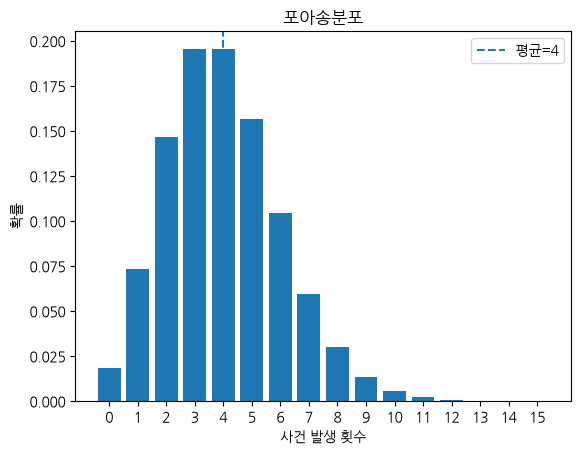

표본평균: 4.00429
표본분산: 4.006611662016621


In [184]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


# 1. 평균 발생 횟수
lam = 4


# 2. 포아송분포 객체
distribution = stats.poisson(
    mu=lam
)


# 3. 가능한 횟수 범위
x = np.arange(
    0,
    16
)


# 4. 확률표
poisson_df = pd.DataFrame({
    "x": x,
    "pmf": distribution.pmf(x),
    "cdf": distribution.cdf(x)
})

print(poisson_df)


# 5. 정확히 2번 발생
print(
    "P(X=2):",
    distribution.pmf(2)
)


# 6. 직접 공식 계산
k = 2

manual_probability = (
    math.exp(-lam)
    * lam ** k
    / math.factorial(k)
)

print(
    "직접 계산 P(X=2):",
    manual_probability
)


# 7. 4번 이하
print(
    "P(X<=4):",
    distribution.cdf(4)
)


# 8. 4번 미만
print(
    "P(X<4):",
    distribution.cdf(3)
)


# 9. 4번 초과
print(
    "P(X>4):",
    distribution.sf(4)
)


# 10. 4번 이상
print(
    "P(X>=4):",
    distribution.sf(3)
)


# 11. 2번 이상 5번 이하
print(
    "P(2<=X<=5):",
    distribution.cdf(5)
    - distribution.cdf(1)
)


# 12. 한 번도 발생하지 않음
print(
    "P(X=0):",
    distribution.pmf(0)
)


# 13. 적어도 한 번 발생
print(
    "P(X>=1):",
    distribution.sf(0)
)


# 14. 평균과 분산
print(
    "평균:",
    distribution.mean()
)

print(
    "분산:",
    distribution.var()
)

print(
    "표준편차:",
    distribution.std()
)


# 15. PMF 그래프
plt.bar(
    x,
    distribution.pmf(x)
)

plt.axvline(
    lam,
    linestyle="--",
    label=f"평균={lam}"
)

plt.xlabel("사건 발생 횟수")
plt.ylabel("확률")
plt.title("포아송분포")
plt.xticks(x)
plt.legend()
plt.show()


# 16. 시뮬레이션
samples = distribution.rvs(
    size=100000,
    random_state=42
)

print(
    "표본평균:",
    samples.mean()
)

print(
    "표본분산:",
    samples.var(ddof=1)
)

In [185]:
calls = stats.poisson(3)
calls

In [186]:
calls.pmf(2)

np.float64(0.22404180765538775)

In [187]:
calls.cdf(2)

np.float64(0.42319008112684364)

In [189]:
1-calls.cdf(2)

np.float64(0.5768099188731564)

In [190]:
calls.pmf(0)

np.float64(0.049787068367863944)

In [191]:
1-calls.pmf(0)

np.float64(0.950212931632136)

In [192]:
calls.mean(), calls.var()

(np.float64(3.0), np.float64(3.0))

In [193]:
calls = stats.poisson(
    mu=3
)

print(
    "P(X=2):",
    calls.pmf(2)
)

print(
    "P(X<=2):",
    calls.cdf(2)
)

print(
    "P(X>=3):",
    calls.sf(2)
)

print(
    "P(X=0):",
    calls.pmf(0)
)

print(
    "P(X>=1):",
    calls.sf(0)
)

print(
    "평균:",
    calls.mean()
)

print(
    "분산:",
    calls.var()
)

P(X=2): 0.22404180765538775
P(X<=2): 0.42319008112684364
P(X>=3): 0.5768099188731566
P(X=0): 0.049787068367863944
P(X>=1): 0.950212931632136
평균: 3.0
분산: 3.0


In [194]:
server = stats.poisson(1.5)

In [195]:
server.pmf(0)

np.float64(0.22313016014842982)

In [197]:
server.pmf(1)

np.float64(0.33469524022264474)

In [202]:
1-server.cdf(1)

np.float64(0.44217459962892525)

In [199]:
7*1.5

10.5

In [200]:
stats.poisson(10.5).pmf(10)

np.float64(0.12360552906286436)

In [201]:
daily_errors = stats.poisson(
    mu=1.5
)

print(
    "P(X=0):",
    daily_errors.pmf(0)
)

print(
    "P(X=1):",
    daily_errors.pmf(1)
)

print(
    "P(X>=2):",
    daily_errors.sf(1)
)

P(X=0): 0.22313016014842982
P(X=1): 0.33469524022264474
P(X>=2): 0.4421745996289252


In [203]:
weekly_errors = stats.poisson(
    mu=1.5 * 7
)

print(
    "주간 평균:",
    weekly_errors.mean()
)

print(
    "P(X=10):",
    weekly_errors.pmf(10)
)

주간 평균: 10.5
P(X=10): 0.12360552906286436


In [204]:
5*0.2

1.0

In [210]:
1-stats.poisson(1).cdf(1)

np.float64(0.26424111765711533)

In [208]:
print(
    "P(X=0):",
    stats.poisson(1).pmf(0)
)

print(
    "P(X=1):",
    stats.poisson(1).pmf(1)
)

print(
    "P(X>=2):",
    stats.poisson(1).sf(1)
)

P(X=0): 0.36787944117144233
P(X=1): 0.36787944117144233
P(X>=2): 0.2642411176571153
